# Original_DSR Binary Ablation Notebook

This notebook is prepared for **Chapter 4.1 Ablation Study Results** and only keeps the **Original_DSR family** to reduce computational cost.

## Ablation design
- **Original_DSR**: baseline lightweight backbone
- **Original_DSR + A**: baseline + **Self-Attention Fusion**
- **Original_DSR + B**: baseline + **Prototype-based RAG Augmentation**
- **Original_DSR + A + B**: baseline + both modules


The dataset still uses the original **four folders**, but the training target remains **binary classification**:
- `normal_ecg_images` -> Normal
- all other folders -> Abnormal


In [1]:
import os, math, random, warnings, json
from pathlib import Path
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
import cv2
import pywt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)
from scipy import signal
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


d:\anaconda\envs\pytorch_ecg\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# =========================
# Paths and hyperparameters
# =========================
BASE_DIR = Path(r"C:\Users\LYG Y9000x\OneDrive\Desktop\proj new daima")
DATA_ROOT = BASE_DIR / "ecg_dataset" / "development"

CLASSES = [
    "normal_ecg_images",
    "abnormal_heartbeat_ecg_images",
    "myocardial_infarction_ecg_images",
    "post_mi_history_ecg_images",
]

CLASS_NAMES = ["Normal", "Abnormal"]
NUM_CLASSES = 2

RR_CSV = r""     # keep empty unless you really have RR features
IMG_SIZE = 224
USE_CWT = True
RR_DIM = 0

BATCH_SIZE = 16
LR = 5e-4
EPOCHS = 40
WEIGHT_DECAY = 1e-4
PATIENCE = 10
SEED = 42
NUM_WORKERS = 0
USE_AMP = torch.cuda.is_available()

OUT_DIR = BASE_DIR / "outputs_ablation_original_dsr_binary"
WEIGHT_DIR = BASE_DIR / "weights_ablation_original_dsr_binary"
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
for d in [OUT_DIR, WEIGHT_DIR, FIG_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

EXTS = ("*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

print("=" * 70)
print("Original_DSR binary ablation")
print(f"BASE_DIR   : {BASE_DIR}")
print(f"DATA_ROOT  : {DATA_ROOT}")
print(f"OUT_DIR    : {OUT_DIR}")
print(f"DEVICE     : {DEVICE}")
print(f"USE_CWT    : {USE_CWT}")
print(f"RR_DIM     : {RR_DIM}")
print(f"NUM_CLASSES: {NUM_CLASSES}")
print("=" * 70)


Original_DSR binary ablation
BASE_DIR   : C:\Users\LYG Y9000x\OneDrive\Desktop\proj new daima
DATA_ROOT  : C:\Users\LYG Y9000x\OneDrive\Desktop\proj new daima\ecg_dataset\development
OUT_DIR    : C:\Users\LYG Y9000x\OneDrive\Desktop\proj new daima\outputs_ablation_original_dsr_binary
DEVICE     : cuda
USE_CWT    : True
RR_DIM     : 0
NUM_CLASSES: 2


,folder,count
0,normal_ecg_images,280
1,abnormal_heartbeat_ecg_images,230
2,myocardial_infarction_ecg_images,238
3,post_mi_history_ecg_images,170


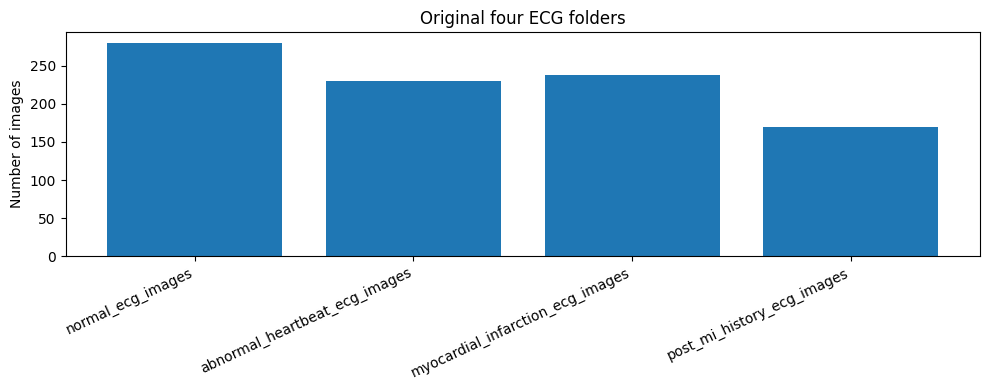

In [3]:
# =========================
# Quick dataset check
# =========================
assert DATA_ROOT.exists(), f"DATA_ROOT not found: {DATA_ROOT}"

counts = []
for cname in CLASSES:
    cdir = DATA_ROOT / cname
    n = 0
    if cdir.exists():
        for ext in EXTS:
            n += len(list(cdir.glob(ext)))
    counts.append({"folder": cname, "count": n})

df_counts = pd.DataFrame(counts)
display(df_counts)

plt.figure(figsize=(10, 4))
plt.bar(df_counts["folder"], df_counts["count"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Number of images")
plt.title("Original four ECG folders")
plt.tight_layout()
plt.savefig(FIG_DIR / "dataset_folder_counts.png", dpi=300, bbox_inches="tight")
plt.show()


In [4]:
# =========================
# Signal extraction helpers
# =========================
def generate_cwt_scalogram(signal_1d, scales=None, wavelet="morl", size=(224, 224)):
    if scales is None:
        scales = np.arange(4, 65)
    coeffs, _ = pywt.cwt(signal_1d, scales, wavelet)
    scalogram = np.log1p(np.abs(coeffs))
    scalogram = (scalogram - scalogram.min()) / (scalogram.max() - scalogram.min() + 1e-8)
    scalogram = cv2.resize(scalogram, size, interpolation=cv2.INTER_LINEAR)
    return scalogram.astype(np.float32)

def detect_r_peaks(signal_1d, fs=500, distance=200):
    b, a = signal.butter(2, [5, 15], btype="band", fs=fs)
    filtered = signal.filtfilt(b, a, signal_1d)
    diff = np.diff(filtered)
    squared = diff ** 2
    window_size = int(0.15 * fs)
    integrated = np.convolve(squared, np.ones(window_size) / window_size, mode="same")
    peaks, _ = signal.find_peaks(integrated, distance=distance, height=np.mean(integrated))
    return peaks

def compute_rr_intervals(r_peaks, fs=500, normalize=True, k=8):
    if len(r_peaks) < 2:
        return np.zeros(k, dtype=np.float32)
    rr = np.diff(r_peaks) / fs * 1000
    if normalize and len(rr) > 0:
        rr = (rr - rr.mean()) / (rr.std() + 1e-6)
    if len(rr) >= k:
        rr = rr[:k]
    else:
        rr = np.pad(rr, (0, k - len(rr)))
    return rr.astype(np.float32)

def crop_rhythm_strip(img_pil: Image.Image, bottom_ratio: float = 0.32) -> Image.Image:
    arr = np.array(img_pil)
    h, w = arr.shape[:2]
    y0 = int(h * (1 - bottom_ratio))
    return Image.fromarray(arr[y0:h, :])

def suppress_grid_gray(gray_u8: np.ndarray) -> np.ndarray:
    g = cv2.GaussianBlur(gray_u8, (3, 3), 0)
    inv = 255 - g
    bw = cv2.adaptiveThreshold(
        inv, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 31, -5
    )
    h, w = bw.shape
    kx = max(10, w // 80)
    ky = max(10, h // 80)
    horiz = cv2.morphologyEx(
        bw, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (kx, 1))
    )
    vert = cv2.morphologyEx(
        bw, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (1, ky))
    )
    grid = cv2.bitwise_or(horiz, vert)
    grid = cv2.dilate(grid, cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)), iterations=1)
    out = gray_u8.copy()
    out[grid > 0] = np.clip(out[grid > 0] + 60, 0, 255)
    return out

def extract_ecg_from_image(image_pil, band_ratio: float = 0.55) -> np.ndarray:
    image_pil = crop_rhythm_strip(image_pil.convert("L"), bottom_ratio=0.32)
    gray = np.array(image_pil, dtype=np.uint8)
    gray = suppress_grid_gray(gray)

    h, w0 = gray.shape
    x0 = int(w0 * 0.06)
    x1 = int(w0 * 0.94)
    gray = gray[:, x0:x1]
    h, w = gray.shape

    y0 = int(h * (0.5 - band_ratio / 2))
    y1 = int(h * (0.5 + band_ratio / 2))
    y0 = max(0, y0)
    y1 = min(h, y1)
    strip = gray[y0:y1, :]
    bh = strip.shape[0]

    inv = 255.0 - strip.astype(np.float32)
    thr = np.percentile(inv, 96)
    wgt = np.clip(inv - thr, 0, None)

    ys = np.arange(bh, dtype=np.float32)[:, None]
    denom = wgt.sum(axis=0)
    denom_thr = np.percentile(denom, 50)
    valid = denom > denom_thr
    yhat = (ys * wgt).sum(axis=0) / (denom + 1e-6)
    yhat[~valid] = np.nan

    x = np.arange(w, dtype=np.float32)
    good = ~np.isnan(yhat)
    if good.sum() >= 2:
        yhat = np.interp(x, x[good], yhat[good])
    else:
        yhat = np.full_like(x, bh / 2.0)

    sig = (bh / 2.0 - yhat)
    k = 31
    sig = np.convolve(sig, np.ones(k, dtype=np.float32) / k, mode="same")

    k2 = 201
    baseline = np.convolve(sig, np.ones(k2, dtype=np.float32) / k2, mode="same")
    sig = sig - baseline

    lo, hi = np.percentile(sig, [1, 99])
    sig = np.clip(sig, lo, hi)
    sig = (sig - sig.mean()) / (sig.std() + 1e-6)

    w = sig.shape[0]
    l = int(w * 0.02)
    r = int(w * 0.98)
    sig_mid = sig[l:r]
    x_old = np.linspace(0, 1, sig_mid.shape[0])
    x_new = np.linspace(0, 1, w)
    sig = np.interp(x_new, x_old, sig_mid).astype(np.float32)
    return sig


In [5]:
# =========================
# Dataset and loaders
# =========================
def map_to_binary_label(folder_name: str) -> int:
    return 0 if folder_name == "normal_ecg_images" else 1

def default_transforms(train=True):
    if train:
        return T.Compose([
            T.Grayscale(num_output_channels=1),
            T.Resize((IMG_SIZE, IMG_SIZE)),
            T.RandomAffine(degrees=8, translate=(0.06, 0.06), scale=(0.92, 1.08), shear=5),
            T.RandomPerspective(distortion_scale=0.25, p=0.4),
            T.ColorJitter(brightness=0.35, contrast=0.35),
            T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.2)),
            T.ToTensor(),
            T.Normalize(mean=[0.5], std=[0.5]),
        ])
    return T.Compose([
        T.Grayscale(num_output_channels=1),
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(mean=[0.5], std=[0.5]),
    ])

def load_rr_map(rr_csv, k=8):
    if not rr_csv or not Path(rr_csv).exists():
        return {}, 0
    df = pd.read_csv(rr_csv)
    rr_cols = [c for c in df.columns if c.lower().startswith("rr")][:k]
    rr_map = {}
    for _, row in df.iterrows():
        key = str(row["filepath"]).replace("\\", "/")
        rr_map[key] = row[rr_cols].astype(float).to_numpy(dtype="float32")
    return rr_map, len(rr_cols)

def _scan_folder(folder: Path) -> List[Path]:
    files = []
    for pat in EXTS:
        files += list(folder.glob(pat))
    return sorted(files)

def list_paths(base_dir: Path) -> List[Tuple[str, int]]:
    items = []
    for cname in CLASSES:
        cls_dir = base_dir / cname
        if cls_dir.exists():
            label = map_to_binary_label(cname)
            for p in _scan_folder(cls_dir):
                items.append((str(p.resolve()), label))
    return items

class ECGFilesDataset(Dataset):
    def __init__(self, items: List[Tuple[str, int]], root, transform=None,
                 rr_map=None, rr_dim=0, train=True, use_cwt=True):
        self.items = items
        self.root = Path(root)
        self.transform = transform or default_transforms(train=train)
        self.rr_map = rr_map or {}
        self.rr_dim = rr_dim
        self.train = train
        self.use_cwt = use_cwt

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        path, y = self.items[i]
        img_pil = Image.open(path).convert("L")

        abs_path = Path(path).resolve()
        abs_root = self.root.resolve()
        rel = str(abs_path.relative_to(abs_root)).replace("\\", "/")

        signal_1d = None
        if self.use_cwt or self.rr_dim > 0:
            signal_1d = extract_ecg_from_image(img_pil)

        if self.use_cwt:
            scalogram = generate_cwt_scalogram(signal_1d, size=(IMG_SIZE, IMG_SIZE))
            img_tensor = torch.from_numpy(scalogram).unsqueeze(0).float()
            img_tensor = (img_tensor - 0.5) / 0.5
        else:
            img_tensor = self.transform(img_pil)

        if self.rr_dim > 0:
            if rel in self.rr_map:
                rr = self.rr_map[rel]
            else:
                try:
                    r_peaks = detect_r_peaks(signal_1d, fs=500)
                    rr = compute_rr_intervals(r_peaks, k=self.rr_dim)
                except Exception:
                    rr = np.zeros(self.rr_dim, dtype=np.float32)
        else:
            rr = np.zeros(0, dtype=np.float32)

        return img_tensor, torch.tensor(rr, dtype=torch.float32), torch.tensor(y, dtype=torch.long), rel

def build_split_manifest(base: Path, seed: int = SEED):
    all_items = list_paths(base)
    assert len(all_items) > 0, f"No images found under {base}"

    by_cls = {}
    for path, lab in all_items:
        by_cls.setdefault(lab, []).append((path, lab))

    rng = np.random.RandomState(seed)
    items_tr, items_va, items_te = [], [], []

    for lab, items in by_cls.items():
        rng.shuffle(items)
        n = len(items)
        n_te = max(1, int(0.1 * n))
        n_va = max(1, int(0.1 * n))
        n_tr = n - n_va - n_te
        if n_tr < 1:
            n_tr = max(1, n - 2)
            n_va = 1
            n_te = n - n_tr - n_va

        items_tr += items[:n_tr]
        items_va += items[n_tr:n_tr + n_va]
        items_te += items[n_tr + n_va:]

    split_rows = []
    for split_name, split_items in [("train", items_tr), ("val", items_va), ("test", items_te)]:
        for path, lab in split_items:
            split_rows.append({"split": split_name, "path": path, "label": lab})
    split_df = pd.DataFrame(split_rows)
    split_df.to_csv(TABLE_DIR / "original_dsr_binary_split_manifest.csv", index=False)

    return items_tr, items_va, items_te, split_df

def make_loaders(rr_csv=RR_CSV, batch=BATCH_SIZE):
    rr_map, rr_dim = load_rr_map(rr_csv)
    base = Path(DATA_ROOT)

    has_train = (base / "train").exists()
    has_val = (base / "val").exists()
    has_test = (base / "test").exists()

    if has_train and has_val and has_test:
        raise NotImplementedError(
            "This notebook is prepared for direct class folders under development/. "
            "If you later create train/val/test folders, adapt this loader block."
        )

    items_tr, items_va, items_te, split_df = build_split_manifest(base)
    print("Auto split complete:")
    print(split_df["split"].value_counts())

    ds_tr = ECGFilesDataset(items_tr, DATA_ROOT, default_transforms(True), rr_map, rr_dim, train=True, use_cwt=USE_CWT)
    ds_va = ECGFilesDataset(items_va, DATA_ROOT, default_transforms(False), rr_map, rr_dim, train=False, use_cwt=USE_CWT)
    ds_te = ECGFilesDataset(items_te, DATA_ROOT, default_transforms(False), rr_map, rr_dim, train=False, use_cwt=USE_CWT)

    labels_tr = [lab for _, lab in items_tr]
    class_count = np.bincount(labels_tr, minlength=NUM_CLASSES).astype(np.float32)
    class_count[class_count == 0] = 1.0
    sample_weights = np.array([1.0 / class_count[lab] for lab in labels_tr], dtype=np.float32)
    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )

    L_tr = DataLoader(ds_tr, batch_size=batch, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
    L_va = DataLoader(ds_va, batch_size=batch, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
    L_te = DataLoader(ds_te, batch_size=batch, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

    return L_tr, L_va, L_te, rr_dim, split_df

L_tr, L_va, L_te, rr_dim, split_df = make_loaders()
print(f"Train batches: {len(L_tr)} | Val batches: {len(L_va)} | Test batches: {len(L_te)} | rr_dim: {rr_dim}")


Auto split complete:
split
train    736
val       91
test      91
Name: count, dtype: int64
Train batches: 46 | Val batches: 6 | Test batches: 6 | rr_dim: 0


Random sample: C:\Users\LYG Y9000x\OneDrive\Desktop\proj new daima\ecg_dataset\development\myocardial_infarction_ecg_images\MI(230).jpg
Mapped binary label: Abnormal
Signal mean/std: -0.00820453092455864 0.9805180430412292


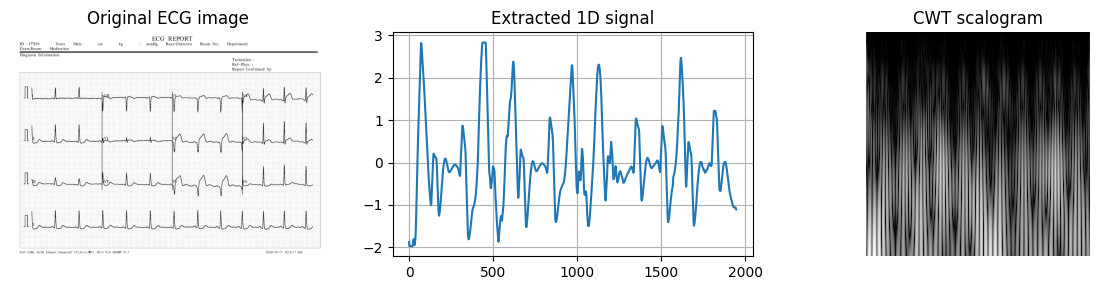

In [6]:
# =========================
# Visual check of one sample
# =========================
items = list_paths(DATA_ROOT)
path, y = random.choice(items)
img = Image.open(path).convert("L")
sig = extract_ecg_from_image(img)
scal = generate_cwt_scalogram(sig, size=(IMG_SIZE, IMG_SIZE))

print("Random sample:", path)
print("Mapped binary label:", CLASS_NAMES[y])
print("Signal mean/std:", float(np.mean(sig)), float(np.std(sig)))

plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original ECG image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.plot(sig)
plt.title("Extracted 1D signal")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.imshow(scal, cmap="gray")
plt.title("CWT scalogram")
plt.axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "signal_and_cwt_demo.png", dpi=300, bbox_inches="tight")
plt.show()


In [7]:
# =========================
# Model blocks
# =========================
class SE2D(nn.Module):
    def __init__(self, c, r=16):
        super().__init__()
        hidden = max(c // r, 4)
        self.fc1 = nn.Conv2d(c, hidden, 1)
        self.fc2 = nn.Conv2d(hidden, c, 1)

    def forward(self, x):
        s = F.adaptive_avg_pool2d(x, 1)
        s = F.relu(self.fc1(s), inplace=True)
        s = torch.sigmoid(self.fc2(s))
        return x * s

class DSRes2D(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.dw = nn.Conv2d(in_c, in_c, 3, stride=stride, padding=1, groups=in_c, bias=False)
        self.pw = nn.Conv2d(in_c, out_c, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(in_c)
        self.bn2 = nn.BatchNorm2d(out_c)
        self.se = SE2D(out_c)
        self.proj = nn.Conv2d(in_c, out_c, 1, stride=stride, bias=False) if (in_c != out_c or stride != 1) else None

    def forward(self, x):
        identity = x
        x = F.relu(self.bn1(self.dw(x)), inplace=True)
        x = self.bn2(self.pw(x))
        x = self.se(F.relu(x, inplace=True))
        if self.proj is not None:
            identity = self.proj(identity)
        return F.relu(x + identity, inplace=True)

class MorphologyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.MaxPool2d(2),
        )
        self.b1 = DSRes2D(32, 64, stride=2)
        self.b2 = DSRes2D(64, 128, stride=2)
        self.b3 = DSRes2D(128, 128, stride=2)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 256),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.b1(x)
        x = self.b2(x)
        x = self.b3(x)
        return self.head(x)

class RR_TCN(nn.Module):
    def __init__(self, rr_dim, out_dim=64):
        super().__init__()
        self.rr_dim = int(rr_dim)
        if self.rr_dim <= 0:
            self.enabled = False
            self.out_dim = 0
            self.net = None
            return
        self.enabled = True
        self.out_dim = out_dim
        self.net = nn.Sequential(
            nn.Linear(self.rr_dim, 128),
            nn.ReLU(True),
            nn.Dropout(0.1),
            nn.Linear(128, out_dim),
            nn.ReLU(True),
        )

    def forward(self, rr):
        if not self.enabled:
            return rr.new_zeros((rr.shape[0], 0))
        return self.net(rr)

class DualBranchSelfAttention(nn.Module):
    def __init__(self, fm_dim=256, fr_dim=64, attn_dim=256, num_heads=4, dropout=0.1):
        super().__init__()
        self.fm_proj = nn.Linear(fm_dim, attn_dim)
        self.fr_proj = nn.Linear(fr_dim, attn_dim) if fr_dim > 0 else None
        self.attn = nn.MultiheadAttention(
            embed_dim=attn_dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )
        self.norm1 = nn.LayerNorm(attn_dim)
        self.norm2 = nn.LayerNorm(attn_dim)
        self.ffn = nn.Sequential(
            nn.Linear(attn_dim, attn_dim),
            nn.ReLU(True),
            nn.Dropout(dropout),
            nn.Linear(attn_dim, attn_dim),
        )
        self.dropout = nn.Dropout(dropout)
        self.has_rr = fr_dim > 0

    def forward(self, fm, fr=None):
        fm_tok = self.fm_proj(fm).unsqueeze(1)
        if self.has_rr and fr is not None and fr.shape[1] > 0:
            fr_tok = self.fr_proj(fr).unsqueeze(1)
            x = torch.cat([fm_tok, fr_tok], dim=1)
        else:
            x = fm_tok
        attn_out, _ = self.attn(x, x, x, need_weights=False)
        x = self.norm1(x + self.dropout(attn_out))
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))
        return x.reshape(x.size(0), -1)

class RAGModule(nn.Module):
    def __init__(self, feature_dim=256, num_prototypes=200, num_classes=2):
        super().__init__()
        self.feature_dim = feature_dim
        self.num_prototypes = num_prototypes
        self.num_classes = num_classes
        self.register_buffer("prototypes", torch.randn(num_prototypes, feature_dim))
        self.register_buffer("prototype_labels", torch.zeros(num_prototypes, dtype=torch.long))
        self.register_buffer("prototype_initialized", torch.tensor(False))
        self.fusion = nn.Sequential(
            nn.Linear(feature_dim * 2, feature_dim),
            nn.ReLU(True),
            nn.Dropout(0.1),
            nn.Linear(feature_dim, feature_dim),
        )
        self.attention = nn.Sequential(
            nn.Linear(feature_dim * 2, 128),
            nn.ReLU(True),
            nn.Linear(128, 1),
            nn.Sigmoid(),
        )

    @torch.no_grad()
    def initialize_prototypes(self, features, labels):
        if bool(self.prototype_initialized):
            return
        device = self.prototypes.device
        features = features.to(device)
        labels = labels.to(device)
        samples_per_class = max(1, self.num_prototypes // self.num_classes)
        protos, proto_labels = [], []
        for c in range(self.num_classes):
            mask = labels == c
            cls_feat = features[mask]
            if cls_feat.numel() == 0:
                continue
            if len(cls_feat) >= samples_per_class:
                idx = torch.randperm(len(cls_feat), device=device)[:samples_per_class]
                chosen = cls_feat[idx]
            else:
                idx = torch.randint(0, len(cls_feat), (samples_per_class,), device=device)
                chosen = cls_feat[idx]
            protos.append(chosen)
            proto_labels.append(torch.full((chosen.shape[0],), c, dtype=torch.long, device=device))
        if protos:
            new_p = torch.cat(protos, dim=0)
            new_l = torch.cat(proto_labels, dim=0)
            self.prototypes[: new_p.shape[0]] = new_p
            self.prototype_labels[: new_l.shape[0]] = new_l
            self.prototype_initialized.fill_(True)

    def retrieve(self, query_features, k=5):
        query_norm = F.normalize(query_features, p=2, dim=1)
        proto_norm = F.normalize(self.prototypes, p=2, dim=1)
        sim = torch.mm(query_norm, proto_norm.t())
        top_sim, top_idx = sim.topk(k, dim=1)
        retrieved_feat = self.prototypes[top_idx]
        retrieved_labels = self.prototype_labels[top_idx]
        return retrieved_feat, retrieved_labels, top_sim

    def forward(self, query_features):
        if not bool(self.prototype_initialized):
            return query_features
        retrieved_feat, _, similarities = self.retrieve(query_features, k=5)
        weights = F.softmax(similarities * 10, dim=1).unsqueeze(2)
        aggregated = (retrieved_feat * weights).sum(dim=1)
        combined = torch.cat([query_features, aggregated], dim=1)
        alpha = self.attention(combined)
        fused = self.fusion(combined)
        return query_features + alpha * fused

class OriginalDSRAblation(nn.Module):
    # A = Self-Attention Fusion
    # B = Prototype-based RAG Augmentation
    def __init__(self, num_classes=2, rr_dim=0, use_attn=False, use_rag=False):
        super().__init__()
        self.use_attn = use_attn
        self.use_rag = use_rag
        self.morph = MorphologyCNN()
        self.rrnet = RR_TCN(rr_dim)

        if self.use_attn:
            self.self_attn_fusion = DualBranchSelfAttention(
                fm_dim=256,
                fr_dim=self.rrnet.out_dim,
                attn_dim=256,
                num_heads=4,
                dropout=0.1,
            )
            attn_out_dim = 256 * 2 if self.rrnet.out_dim > 0 else 256
            self.fuse = nn.Sequential(
                nn.Linear(attn_out_dim, 256),
                nn.ReLU(True),
                nn.Dropout(0.2),
            )
        else:
            fuse_in = 256 + self.rrnet.out_dim
            self.fuse = nn.Sequential(
                nn.Linear(fuse_in, 256),
                nn.ReLU(True),
                nn.Dropout(0.2),
            )

        if self.use_rag:
            self.rag = RAGModule(feature_dim=256, num_prototypes=200, num_classes=num_classes)

        self.cls = nn.Linear(256, num_classes)

    def extract_features(self, img, rr):
        fm = self.morph(img)
        fr = self.rrnet(rr)
        if self.use_attn:
            z = self.self_attn_fusion(fm, fr)
        else:
            z = torch.cat([fm, fr], dim=1)
        z = self.fuse(z)
        return z

    def forward(self, img, rr):
        z = self.extract_features(img, rr)
        if self.use_rag:
            z = self.rag(z)
        return self.cls(z)

print("Model blocks ready.")


Model blocks ready.


In [8]:
# =========================
# Training helpers
# =========================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.8, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce)
        loss = self.alpha * (1 - pt) ** self.gamma * ce
        return loss.mean()

def compute_metrics(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "specificity": tn / max(tn + fp, 1),
        "confusion_matrix": cm,
    }
    try:
        out["roc_auc"] = roc_auc_score(y_true, y_prob[:, 1])
    except Exception:
        out["roc_auc"] = np.nan
    try:
        out["pr_auc"] = average_precision_score(y_true, y_prob[:, 1])
    except Exception:
        out["pr_auc"] = np.nan
    return out

def run_epoch(model, loader, optimizer=None, criterion=None, train=True, scaler=None):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_y, all_prob, all_pred = [], [], []

    for imgs, rr, labels, _ in tqdm(loader, leave=False):
        imgs = imgs.to(DEVICE)
        rr = rr.to(DEVICE)
        labels = labels.to(DEVICE)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(scaler is not None and USE_AMP)):
            logits = model(imgs, rr)
            loss = criterion(logits, labels) if criterion is not None else None

        if train:
            if scaler is not None and USE_AMP:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

        probs = F.softmax(logits, dim=1).detach().cpu().numpy()
        preds = probs.argmax(axis=1)
        all_prob.append(probs)
        all_pred.append(preds)
        all_y.append(labels.detach().cpu().numpy())
        total_loss += 0.0 if loss is None else float(loss.detach().cpu().item())

    y_true = np.concatenate(all_y)
    y_prob = np.concatenate(all_prob)
    y_pred = np.concatenate(all_pred)

    metrics = compute_metrics(y_true, y_pred, y_prob)
    metrics["loss"] = total_loss / max(len(loader), 1)
    return metrics, y_true, y_prob

@torch.no_grad()
def initialize_rag_prototypes(model, loader):
    if not getattr(model, "use_rag", False):
        return
    model.eval()
    feat_list, lab_list = [], []
    for imgs, rr, labels, _ in tqdm(loader, desc="Init RAG", leave=False):
        imgs = imgs.to(DEVICE)
        rr = rr.to(DEVICE)
        feats = model.extract_features(imgs, rr)
        feat_list.append(feats.detach())
        lab_list.append(labels.to(DEVICE))
    feats = torch.cat(feat_list, dim=0)
    labs = torch.cat(lab_list, dim=0)
    model.rag.initialize_prototypes(feats, labs)

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_single_variant(variant_name, use_attn=False, use_rag=False, epochs=EPOCHS):
    torch.cuda.empty_cache()

    model = OriginalDSRAblation(
        num_classes=NUM_CLASSES,
        rr_dim=rr_dim,
        use_attn=use_attn,
        use_rag=use_rag,
    ).to(DEVICE)

    criterion = FocalLoss(alpha=0.8, gamma=2.0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    if use_rag:
        initialize_rag_prototypes(model, L_tr)

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "train_f1": [], "val_f1": [],
        "train_auc": [], "val_auc": [],
        "train_pr_auc": [], "val_pr_auc": [],
    }

    best_state = None
    best_val_f1 = -1.0
    patience_counter = 0

    print("=" * 80)
    print(f"Training {variant_name}")
    print(f"use_attn={use_attn}, use_rag={use_rag}, params={count_trainable_params(model):,}")
    print("=" * 80)

    for epoch in range(epochs):
        train_metrics, _, _ = run_epoch(model, L_tr, optimizer, criterion, train=True, scaler=scaler)
        val_metrics, _, _ = run_epoch(model, L_va, None, criterion, train=False, scaler=None)
        scheduler.step()

        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["train_acc"].append(train_metrics["accuracy"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["train_f1"].append(train_metrics["f1"])
        history["val_f1"].append(val_metrics["f1"])
        history["train_auc"].append(train_metrics["roc_auc"])
        history["val_auc"].append(val_metrics["roc_auc"])
        history["train_pr_auc"].append(train_metrics["pr_auc"])
        history["val_pr_auc"].append(val_metrics["pr_auc"])

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss {train_metrics['loss']:.4f} | "
            f"Val Loss {val_metrics['loss']:.4f} | "
            f"Val Acc {val_metrics['accuracy']:.4f} | "
            f"Val F1 {val_metrics['f1']:.4f} | "
            f"Val ROC-AUC {val_metrics['roc_auc']:.4f} | "
            f"Val PR-AUC {val_metrics['pr_auc']:.4f}"
        )

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0

            ckpt_path = WEIGHT_DIR / f"{variant_name}_best.pth"
            torch.save({
                "model_state_dict": best_state,
                "best_val_f1": best_val_f1,
                "config": {
                    "use_attn": use_attn,
                    "use_rag": use_rag,
                    "rr_dim": rr_dim,
                    "num_classes": NUM_CLASSES,
                },
                "history": history,
            }, ckpt_path)
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    test_metrics, y_true, y_prob = run_epoch(model, L_te, None, criterion, train=False, scaler=None)
    test_metrics["params"] = count_trainable_params(model)

    print("Test results:")
    for k in ["accuracy", "precision", "recall", "specificity", "f1", "roc_auc", "pr_auc", "params"]:
        print(f"{k:12s}: {test_metrics[k]}")
    print("Confusion matrix:\n", test_metrics["confusion_matrix"])

    return model, history, test_metrics, y_true, y_prob


In [9]:
# =========================
# Run the four ablation variants
# =========================
ABLATION_CONFIGS = [
    ("Original_DSR", False, False),
    ("Original_DSR_Attn", True, False),
    ("Original_DSR_RAG", False, True),
    ("Original_DSR_Attn_RAG", True, True),
]

results = {
    "models": {},
    "histories": {},
    "metrics": {},
    "predictions": {},
}

for variant_name, use_attn, use_rag in ABLATION_CONFIGS:
    model, history, metrics, y_true, y_prob = train_single_variant(
        variant_name=variant_name,
        use_attn=use_attn,
        use_rag=use_rag,
        epochs=EPOCHS,
    )
    results["models"][variant_name] = model
    results["histories"][variant_name] = history
    results["metrics"][variant_name] = metrics
    results["predictions"][variant_name] = {"y_true": y_true, "y_prob": y_prob}

print("All ablation runs finished.")


Training Original_DSR
use_attn=False, use_rag=False, params=160,982


Epoch 01/40 | Train Loss 0.1369 | Val Loss 0.1641 | Val Acc 0.3077 | Val F1 0.0000 | Val ROC-AUC 0.5505 | Val PR-AUC 0.7525


Epoch 02/40 | Train Loss 0.1359 | Val Loss 0.1440 | Val Acc 0.4945 | Val F1 0.4651 | Val ROC-AUC 0.6281 | Val PR-AUC 0.8099


Epoch 03/40 | Train Loss 0.1152 | Val Loss 0.1950 | Val Acc 0.4505 | Val F1 0.3421 | Val ROC-AUC 0.8209 | Val PR-AUC 0.9120


Epoch 04/40 | Train Loss 0.0892 | Val Loss 0.1114 | Val Acc 0.7143 | Val F1 0.7547 | Val ROC-AUC 0.8571 | Val PR-AUC 0.9324


...

Epoch 23/40 | Train Loss 0.0101 | Val Loss 0.0608 | Val Acc 0.9341 | Val F1 0.9508 | Val ROC-AUC 0.9671 | Val PR-AUC 0.9754


Epoch 24/40 | Train Loss 0.0047 | Val Loss 0.0442 | Val Acc 0.9560 | Val F1 0.9677 | Val ROC-AUC 0.9762 | Val PR-AUC 0.9838


Epoch 25/40 | Train Loss 0.0073 | Val Loss 0.0455 | Val Acc 0.9451 | Val F1 0.9593 | Val ROC-AUC 0.9722 | Val PR-AUC 0.9796


Epoch 26/40 | Train Loss 0.0019 | Val Loss 0.0785 | Val Acc 0.9341 | Val F1 0.9508 | Val ROC-AUC 0.9711 | Val PR-AUC 0.9763
Early stopping at epoch 26


Test results:
accuracy    : 0.8901098901098901
precision   : 0.9344262295081968
recall      : 0.9047619047619048
specificity : 0.8571428571428571
f1          : 0.9193548387096774
roc_auc     : 0.9336734693877551
pr_auc      : 0.9643370068545956
params      : 885463
Confusion matrix:
 [[24  4]
 [ 6 57]]
All ablation runs finished.


In [10]:
# =========================
# Save ablation summary table
# =========================
summary_rows = []
for variant_name, m in results["metrics"].items():
    summary_rows.append({
        "Variant": variant_name,
        "Params": int(m["params"]),
        "Accuracy": m["accuracy"],
        "Precision": m["precision"],
        "Recall": m["recall"],
        "Specificity": m["specificity"],
        "F1": m["f1"],
        "ROC_AUC": m["roc_auc"],
        "PR_AUC": m["pr_auc"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values("F1", ascending=False).reset_index(drop=True)
summary_csv = TABLE_DIR / "original_dsr_ablation_summary.csv"
summary_df.to_csv(summary_csv, index=False)

display(summary_df)
print("Saved:", summary_csv)


,Variant,Params,Accuracy,Precision,Recall,Specificity,F1,ROC_AUC,PR_AUC
0,Original_DSR_Attn_RAG,885463,0.890110,0.934426,0.904762,0.857143,0.919355,0.933673,0.964337
1,Original_DSR,160982,0.879121,0.919355,0.904762,0.821429,0.912000,0.922336,0.941483
2,Original_DSR_RAG,423895,0.857143,0.931034,0.857143,0.857143,0.892562,0.923469,0.959894
3,Original_DSR_Attn,622550,0.846154,0.901639,0.873016,0.785714,0.887097,0.933107,0.960884


Saved: C:\Users\LYG Y9000x\OneDrive\Desktop\proj new daima\outputs_ablation_original_dsr_binary\tables\original_dsr_ablation_summary.csv


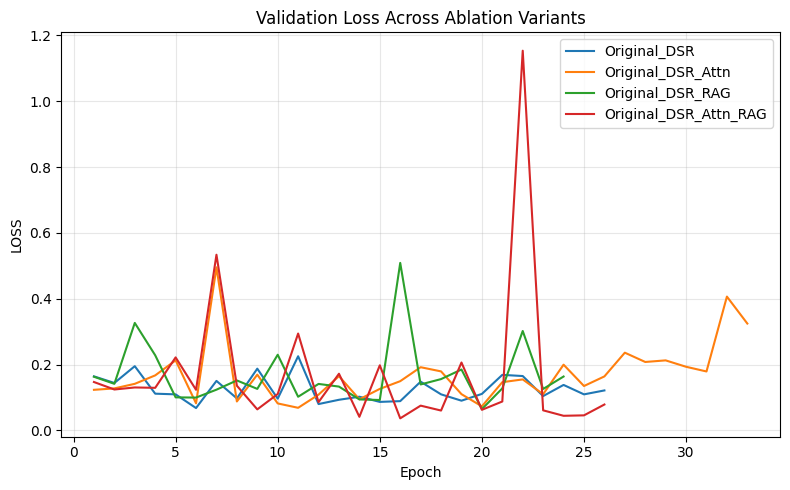

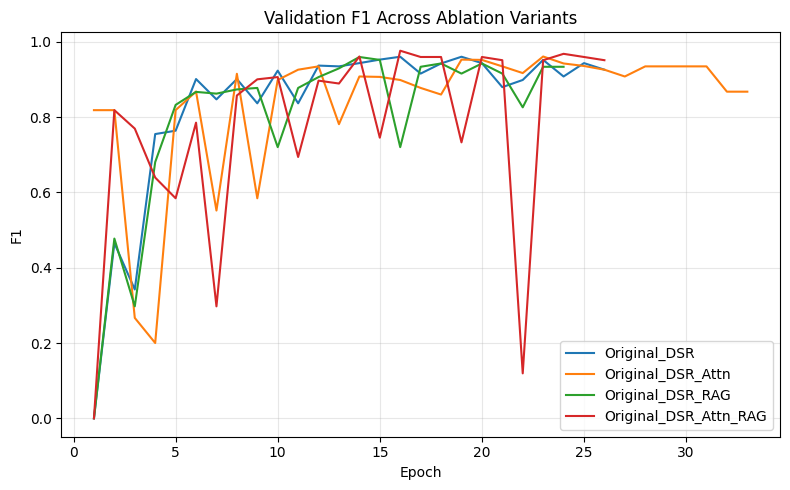

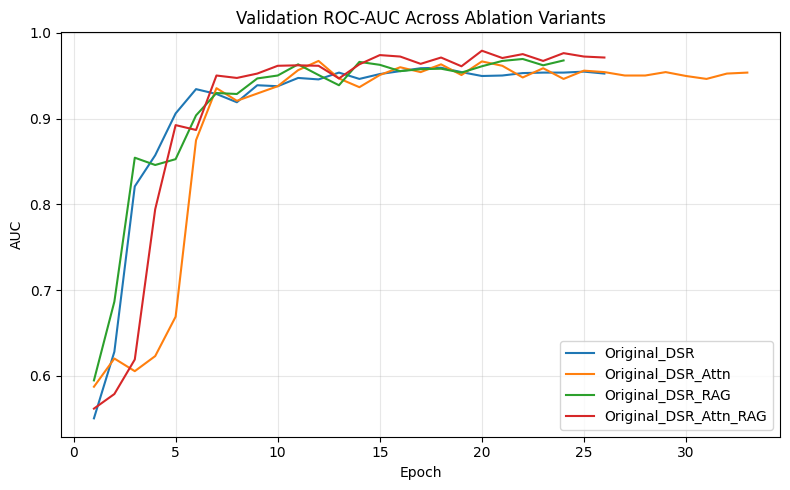

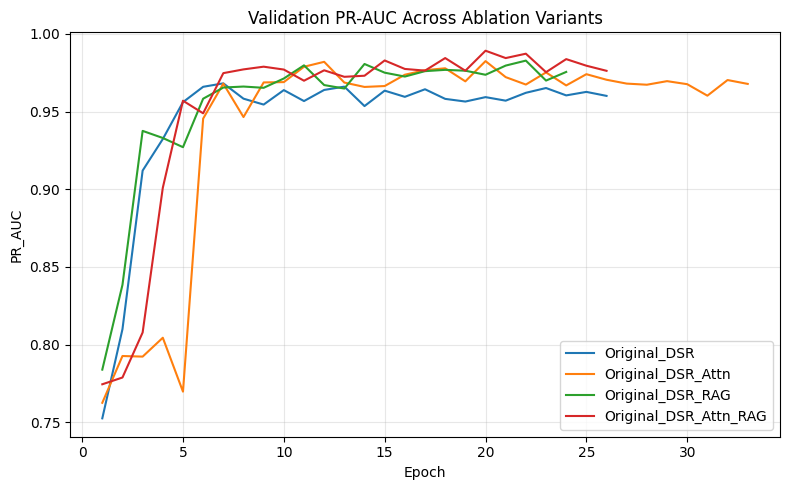

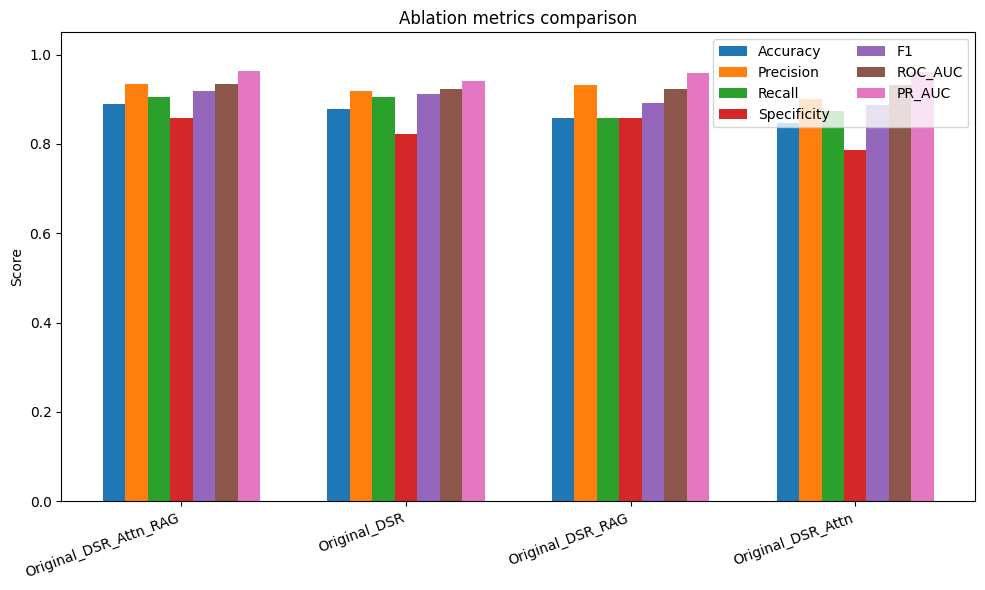

In [ ]:
# =========================
# Plot curves and metric comparison
# =========================
def plot_metric_curves(results, metric_key_val, title, save_name):
    plt.figure(figsize=(8, 5))
    for variant_name, hist in results["histories"].items():
        epochs = np.arange(1, len(hist[metric_key_val]) + 1)
        plt.plot(epochs, hist[metric_key_val], label=variant_name)
    plt.xlabel("Epoch")
    plt.ylabel(metric_key_val.replace("val_", "").upper())
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / save_name, dpi=300, bbox_inches="tight")
    plt.show()

plot_metric_curves(results, "val_loss", "Validation Loss Across Ablation Variants", "ablation_val_loss.png")
plot_metric_curves(results, "val_f1", "Validation F1 Across Ablation Variants", "ablation_val_f1.png")
plot_metric_curves(results, "val_auc", "Validation ROC-AUC Across Ablation Variants", "ablation_val_auc.png")
plot_metric_curves(results, "val_pr_auc", "Validation PR-AUC Across Ablation Variants", "ablation_val_pr_auc.png")

plot_df = summary_df.copy()
metric_cols = ["Accuracy", "Precision", "Recall", "Specificity", "F1", "ROC_AUC", "PR_AUC"]

plt.figure(figsize=(10, 6))
x = np.arange(len(plot_df))
width = 0.1
for i, col in enumerate(metric_cols):
    plt.bar(x + i * width, plot_df[col].values, width=width, label=col)
plt.xticks(x + width * (len(metric_cols) - 1) / 2, plot_df["Variant"], rotation=20, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Ablation metrics comparison")
plt.legend(ncol=2)
plt.tight_layout()
plt.savefig(FIG_DIR / "ablation_metrics_grouped_bar.png", dpi=300, bbox_inches="tight")
plt.show()


## Writing hint for Chapter 4.1

After the notebook finishes, use the generated CSV and figures to write the section in this order:

- Compare **Original_DSR** with **Original_DSR_Attn** for **4.1.1 Effect of Self-Attention Fusion**
- Compare **Original_DSR** with **Original_DSR_RAG** for **4.1.2 Effect of Prototype-based RAG Augmentation**
- Compare all four variants, then focus on **Original_DSR_Attn_RAG** for **4.1.3 Combined Effect of Both Modules**

The main result table is:

`outputs_ablation_original_dsr_binary/tables/original_dsr_ablation_summary.csv`


In [12]:
# Optional: save a compact JSON copy of the final results
json_ready = {}
for variant_name, m in results["metrics"].items():
    json_ready[variant_name] = {
        "accuracy": float(m["accuracy"]),
        "precision": float(m["precision"]),
        "recall": float(m["recall"]),
        "specificity": float(m["specificity"]),
        "f1": float(m["f1"]),
        "roc_auc": float(m["roc_auc"]) if not np.isnan(m["roc_auc"]) else None,
        "pr_auc": float(m["pr_auc"]) if not np.isnan(m["pr_auc"]) else None,
        "params": int(m["params"]),
        "confusion_matrix": np.asarray(m["confusion_matrix"]).tolist(),
    }

json_path = TABLE_DIR / "original_dsr_ablation_summary.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(json_ready, f, indent=2, ensure_ascii=False)

print("Saved:", json_path)


Saved: C:\Users\LYG Y9000x\OneDrive\Desktop\proj new daima\outputs_ablation_original_dsr_binary\tables\original_dsr_ablation_summary.json


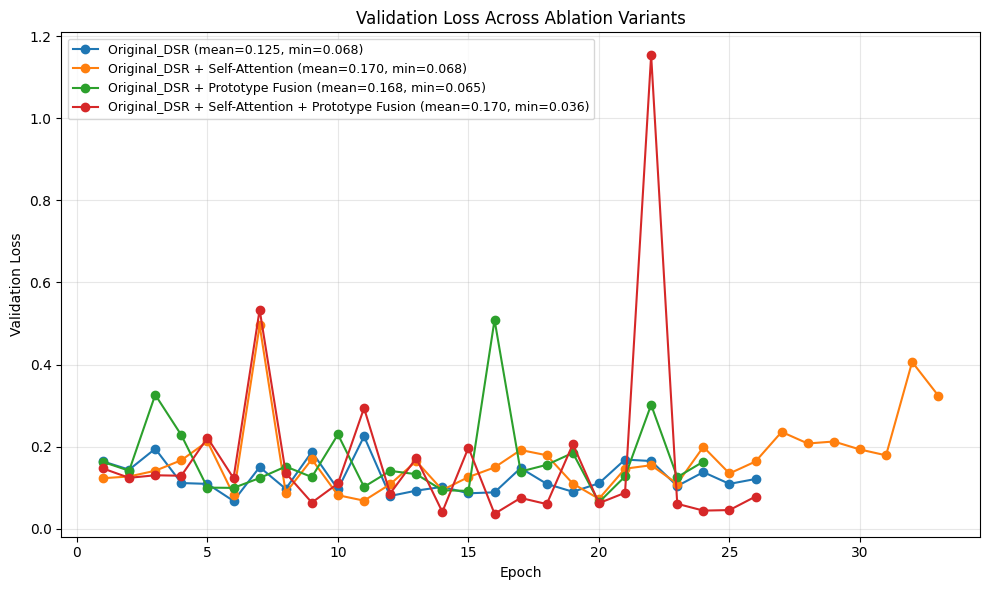

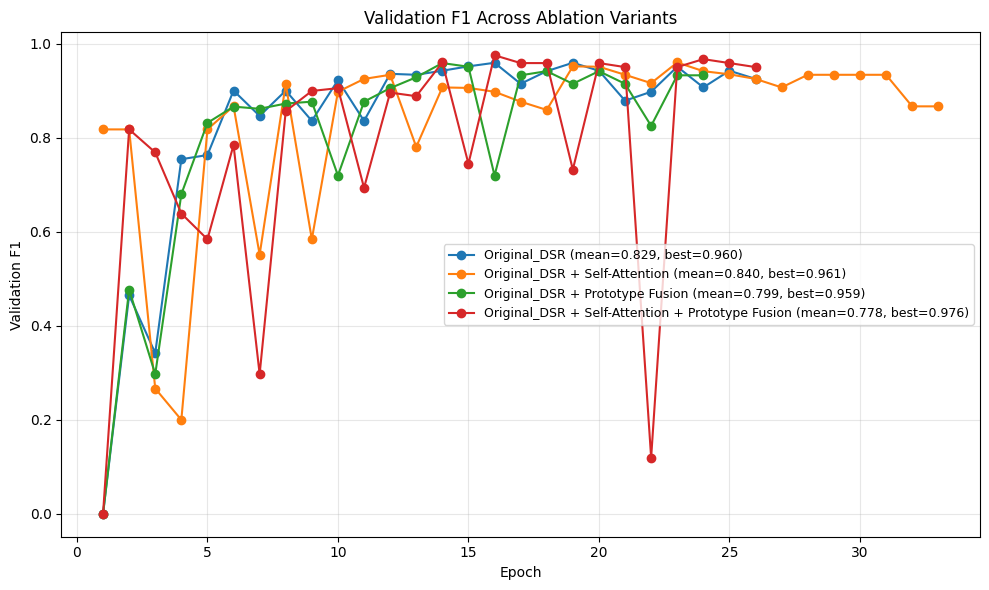

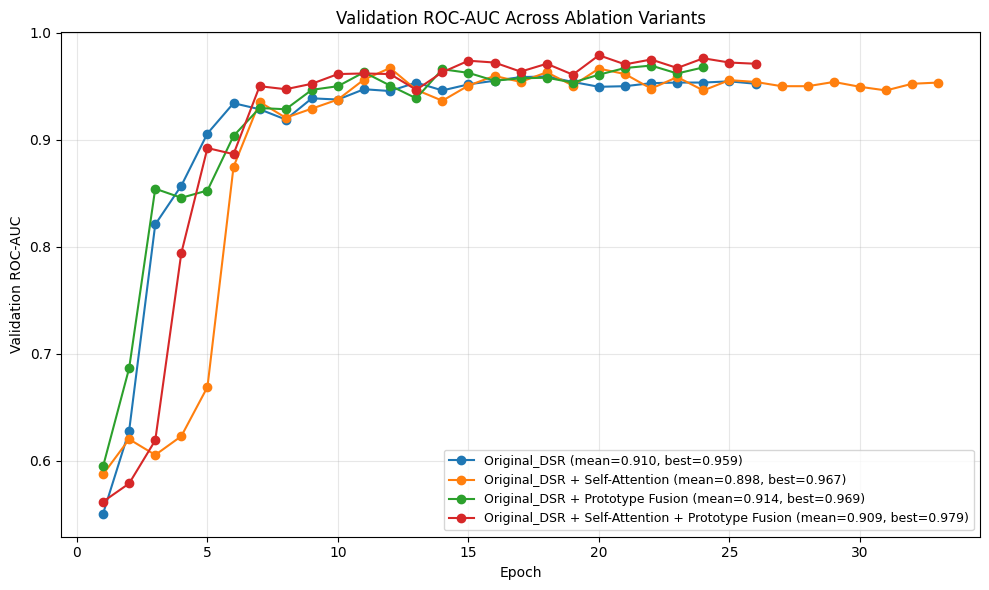

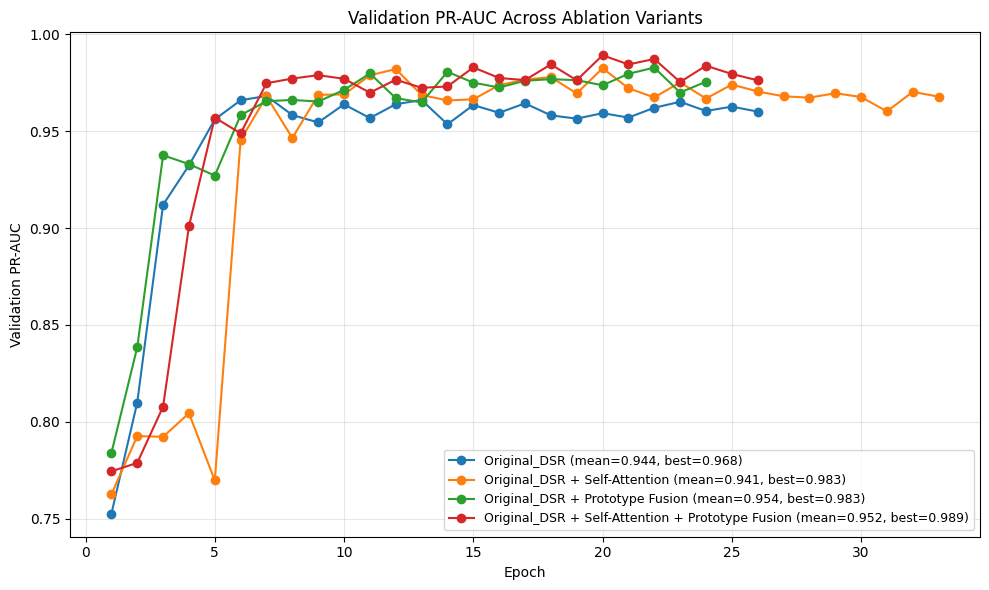

In [14]:
# =========================
# Cleaner curve plots
# No point-wise numeric labels
# Show summary stats in legend instead
# =========================
import numpy as np
import matplotlib.pyplot as plt

VARIANT_NAME_MAP = {
    "Original_DSR": "Original_DSR",
    "Original_DSR_Attn": "Original_DSR + Self-Attention",
    "Original_DSR_RAG": "Original_DSR + Prototype Fusion",
    "Original_DSR_Attn_RAG": "Original_DSR + Self-Attention + Prototype Fusion",
    "original_dsr": "Original_DSR",
    "original_dsr_attn": "Original_DSR + Self-Attention",
    "original_dsr_rag": "Original_DSR + Prototype Fusion",
    "original_dsr_attn_rag": "Original_DSR + Self-Attention + Prototype Fusion",
}

def rename_variant(name):
    return VARIANT_NAME_MAP.get(name, name.replace("RAG", "Prototype Fusion"))

def make_curve_label(metric_key, variant_name, values):
    values = np.array(values, dtype=float)
    mean_v = values.mean()

    if metric_key == "val_loss":
        best_v = values.min()
        return f"{rename_variant(variant_name)} (mean={mean_v:.3f}, min={best_v:.3f})"
    else:
        best_v = values.max()
        return f"{rename_variant(variant_name)} (mean={mean_v:.3f}, best={best_v:.3f})"

def plot_metric_curves(results, metric_key_val, title, save_name):
    plt.figure(figsize=(10, 6))

    for variant_name, hist in results["histories"].items():
        if metric_key_val not in hist or len(hist[metric_key_val]) == 0:
            continue

        epochs = np.arange(1, len(hist[metric_key_val]) + 1)
        values = np.array(hist[metric_key_val], dtype=float)

        label_name = make_curve_label(metric_key_val, variant_name, values)
        plt.plot(epochs, values, marker="o", label=label_name)

    ylabel_map = {
        "val_loss": "Validation Loss",
        "val_f1": "Validation F1",
        "val_auc": "Validation ROC-AUC",
        "val_pr_auc": "Validation PR-AUC"
    }

    plt.xlabel("Epoch")
    plt.ylabel(ylabel_map.get(metric_key_val, metric_key_val.replace("val_", "").upper()))
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(FIG_DIR / save_name, dpi=300, bbox_inches="tight")
    plt.show()


plot_metric_curves(
    results,
    "val_loss",
    "Validation Loss Across Ablation Variants",
    "ablation_val_loss.png"
)

plot_metric_curves(
    results,
    "val_f1",
    "Validation F1 Across Ablation Variants",
    "ablation_val_f1.png"
)

plot_metric_curves(
    results,
    "val_auc",
    "Validation ROC-AUC Across Ablation Variants",
    "ablation_val_auc.png"
)

plot_metric_curves(
    results,
    "val_pr_auc",
    "Validation PR-AUC Across Ablation Variants",
    "ablation_val_pr_auc.png"
)

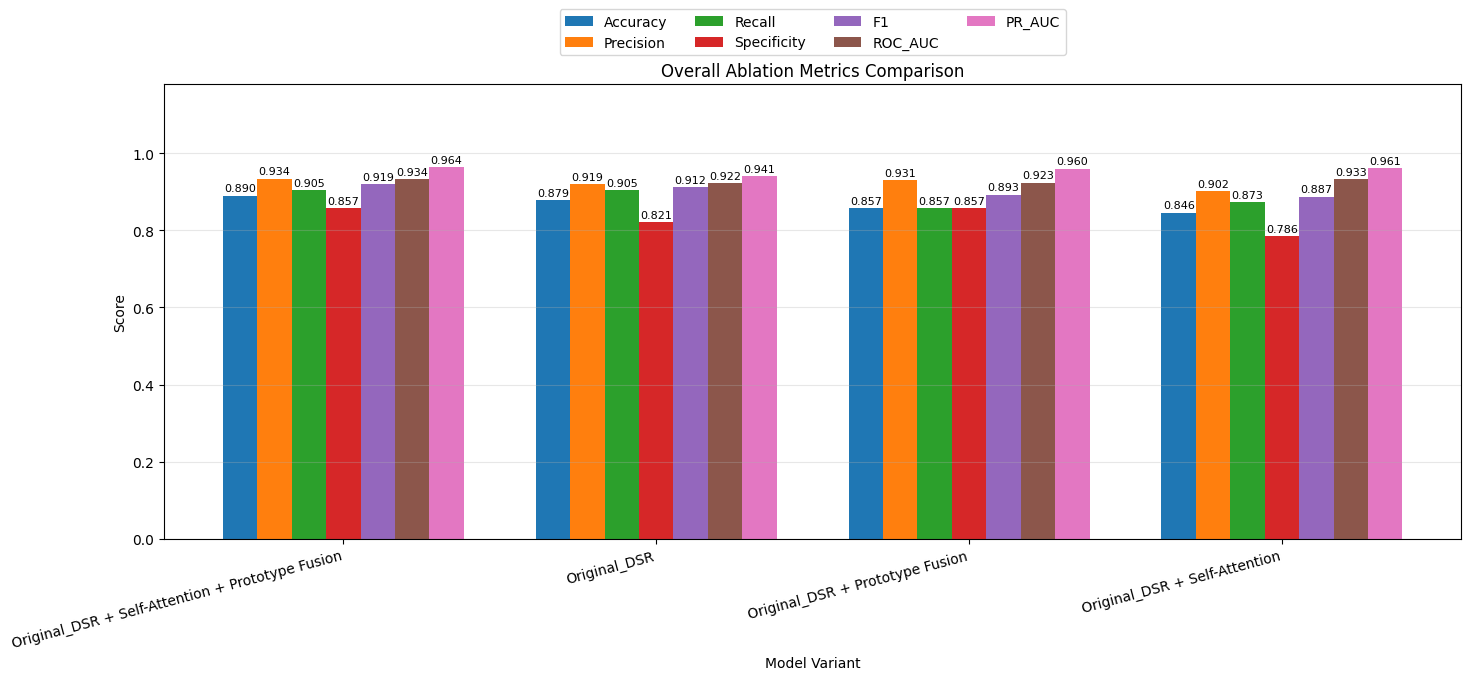

In [17]:
# =========================
# Overall metric comparison
# Fix legend overlap
# =========================
import numpy as np
import matplotlib.pyplot as plt

VARIANT_NAME_MAP = {
    "Original_DSR": "Original_DSR",
    "Original_DSR_Attn": "Original_DSR + Self-Attention",
    "Original_DSR_RAG": "Original_DSR + Prototype Fusion",
    "Original_DSR_Attn_RAG": "Original_DSR + Self-Attention + Prototype Fusion",
    "original_dsr": "Original_DSR",
    "original_dsr_attn": "Original_DSR + Self-Attention",
    "original_dsr_rag": "Original_DSR + Prototype Fusion",
    "original_dsr_attn_rag": "Original_DSR + Self-Attention + Prototype Fusion",
}

def rename_variant(name):
    return VARIANT_NAME_MAP.get(name, name.replace("RAG", "Prototype Fusion"))

def annotate_bars(bars, fontsize=8, offset=0.008):
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            h + offset,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=fontsize,
            rotation=0,
            clip_on=False
        )

plot_df = summary_df.copy()
plot_df["Variant"] = plot_df["Variant"].apply(rename_variant)

metric_cols = ["Accuracy", "Precision", "Recall", "Specificity", "F1", "ROC_AUC", "PR_AUC"]

for col in metric_cols:
    plot_df[col] = plot_df[col].astype(float)

fig, ax = plt.subplots(figsize=(15, 8))

x = np.arange(len(plot_df))
width = 0.11

for i, col in enumerate(metric_cols):
    vals = plot_df[col].values
    bars = ax.bar(x + i * width, vals, width=width, label=col)
    annotate_bars(bars, fontsize=8, offset=0.006)

ax.set_xticks(x + width * (len(metric_cols) - 1) / 2)
ax.set_xticklabels(plot_df["Variant"], rotation=15, ha="right")

ax.set_ylim(0, 1.18)
ax.set_xlabel("Model Variant")
ax.set_ylabel("Score")
ax.set_title("Overall Ablation Metrics Comparison")
ax.grid(axis="y", alpha=0.3)

# 把 legend 放到图外上方
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=4,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig(FIG_DIR / "overall_ablation_metrics_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [28]:
print(summary_df)
print(results["metrics"])

                 Variant  Params  Accuracy  Precision    Recall  Specificity  \
0  Original_DSR_Attn_RAG  885463  0.890110   0.934426  0.904762     0.857143   
1           Original_DSR  160982  0.879121   0.919355  0.904762     0.821429   
2       Original_DSR_RAG  423895  0.857143   0.931034  0.857143     0.857143   
3      Original_DSR_Attn  622550  0.846154   0.901639  0.873016     0.785714   

         F1   ROC_AUC    PR_AUC  
0  0.919355  0.933673  0.964337  
1  0.912000  0.922336  0.941483  
2  0.892562  0.923469  0.959894  
3  0.887097  0.933107  0.960884  
{'Original_DSR': {'accuracy': 0.8791208791208791, 'precision': 0.9193548387096774, 'recall': 0.9047619047619048, 'f1': 0.912, 'specificity': np.float64(0.8214285714285714), 'confusion_matrix': array([[23,  5],
       [ 6, 57]]), 'roc_auc': np.float64(0.9223356009070295), 'pr_auc': np.float64(0.941482539375389), 'loss': 0.14991359816243252, 'params': 160982}, 'Original_DSR_Attn': {'accuracy': 0.8461538461538461, 'precision': 0

In [23]:
def prepare_binary_score(y_score):
    """
    Convert model output scores to 1D positive-class score for binary ROC/PR.
    Supported:
    - shape (N,) -> return as is
    - shape (N, 1) -> squeeze
    - shape (N, 2) -> take positive-class probability at column 1
    """
    if y_score is None:
        return None

    y_score = np.asarray(y_score)

    if y_score.ndim == 1:
        return y_score

    if y_score.ndim == 2:
        if y_score.shape[1] == 1:
            return y_score[:, 0]
        elif y_score.shape[1] == 2:
            return y_score[:, 1]
        else:
            raise ValueError(f"Unsupported y_score shape for binary task: {y_score.shape}")

    raise ValueError(f"Unsupported y_score ndim: {y_score.ndim}, shape={y_score.shape}")


[Original_DSR]
y_true: (91,)
y_pred: (91,)
y_score: (91,)


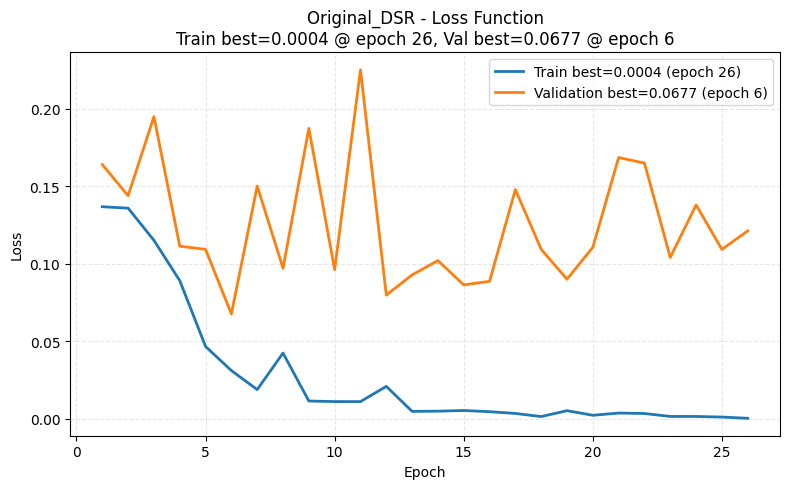

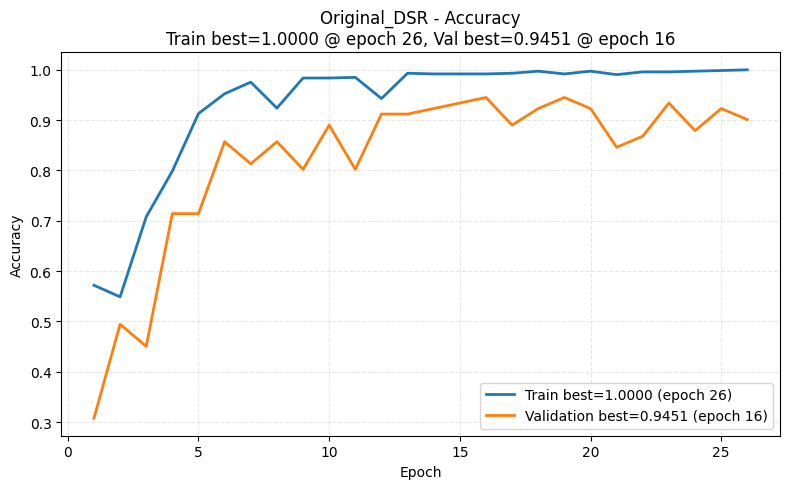

Skip Original_DSR - Specificity (SP): missing train_specificity or val_specificity
Skip Original_DSR - Sensitivity / Recall (SE): missing train_recall or val_recall
Skip Original_DSR - Precision: missing train_precision or val_precision


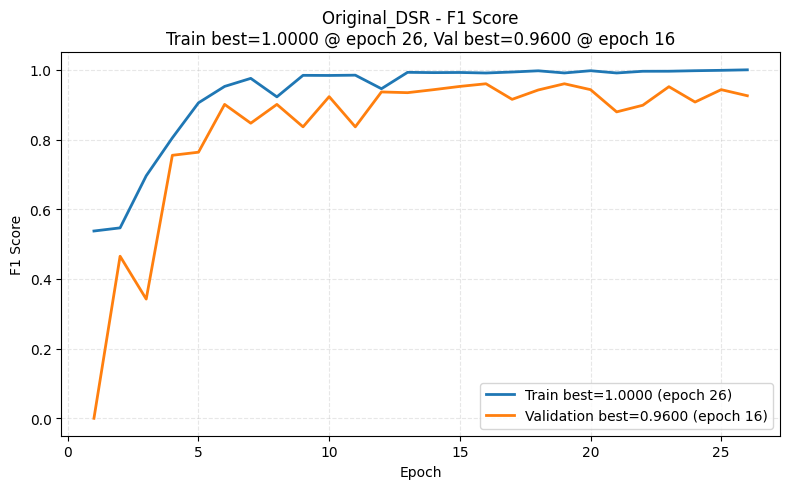

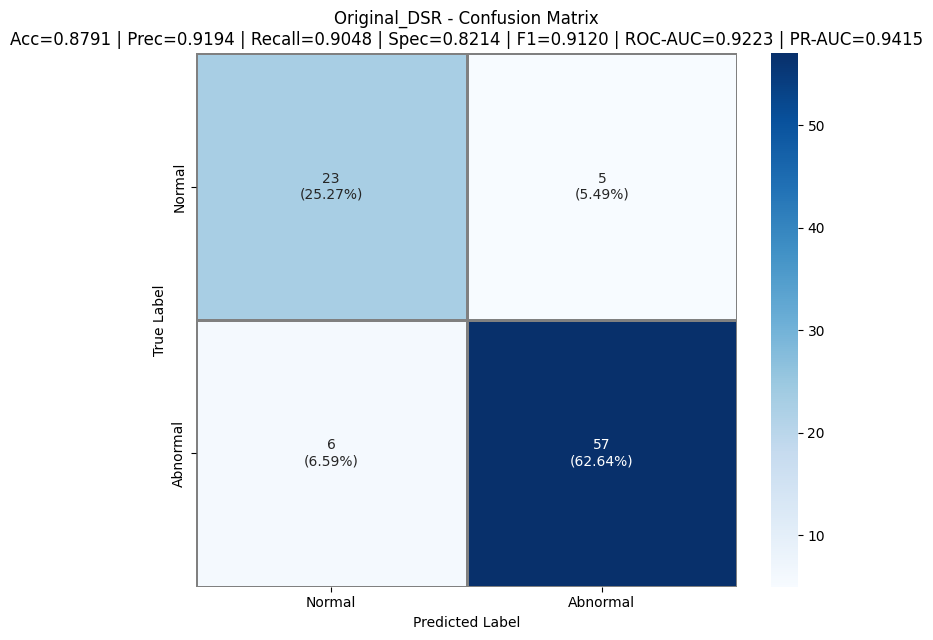

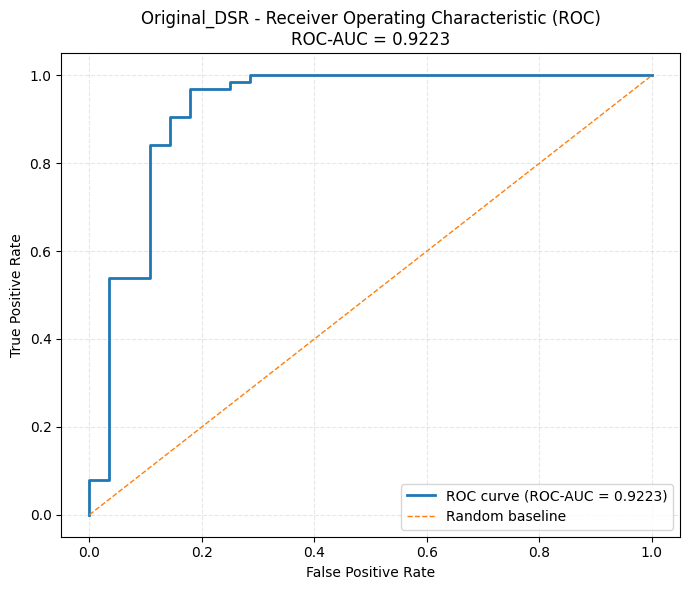

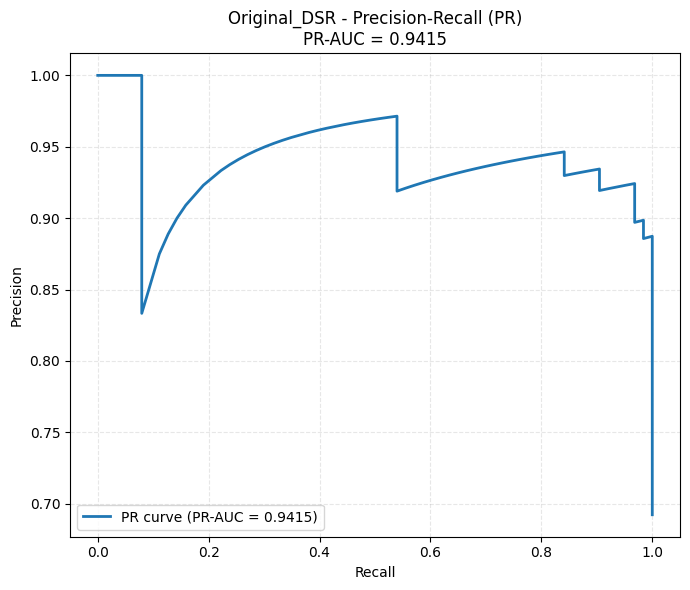

Saved 9 figures for Original_DSR -> C:\Users\LYG Y9000x\OneDrive\Desktop\proj new daima\outputs_ablation_original_dsr_binary\single_method_figures\Original_DSR
ROC-AUC (calculated): 0.9223
PR-AUC (calculated): 0.9415

[Original_DSR_Attn]
y_true: (91,)
y_pred: (91,)
y_score: (91,)


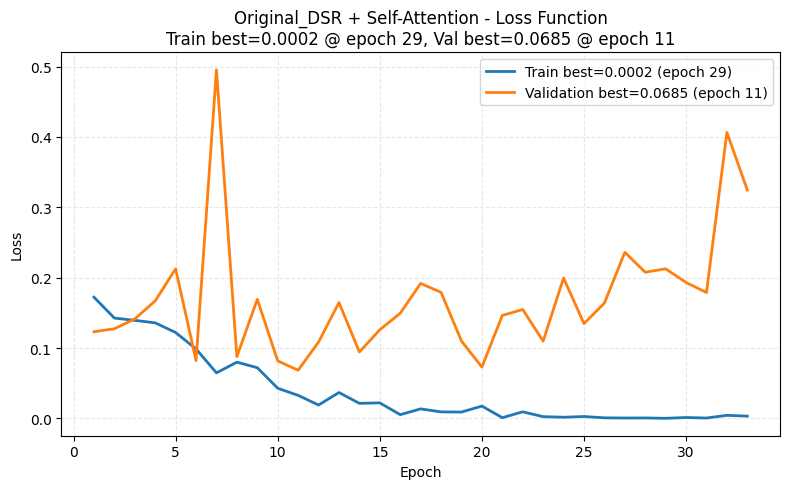

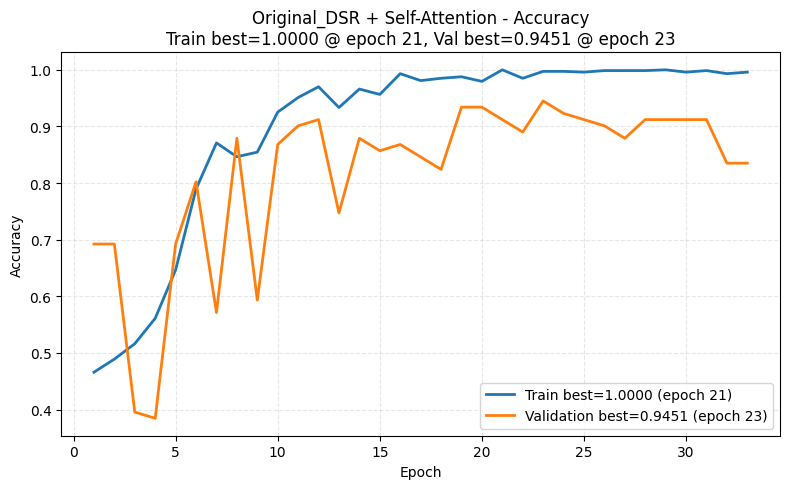

Skip Original_DSR + Self-Attention - Specificity (SP): missing train_specificity or val_specificity
Skip Original_DSR + Self-Attention - Sensitivity / Recall (SE): missing train_recall or val_recall
Skip Original_DSR + Self-Attention - Precision: missing train_precision or val_precision


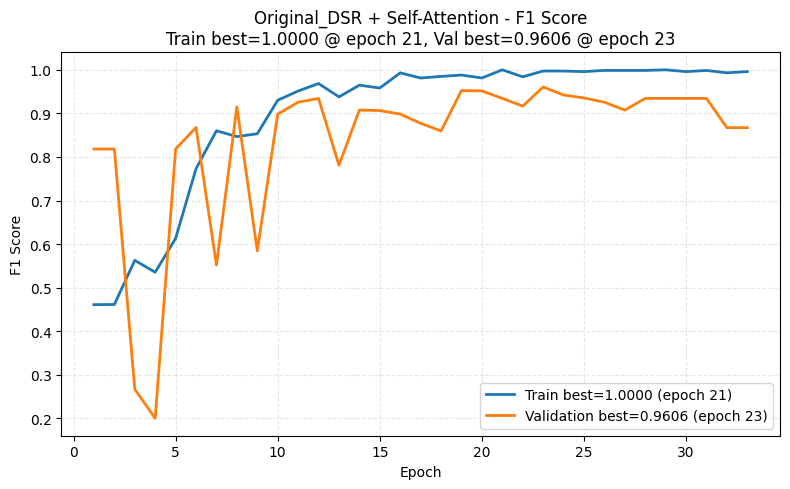

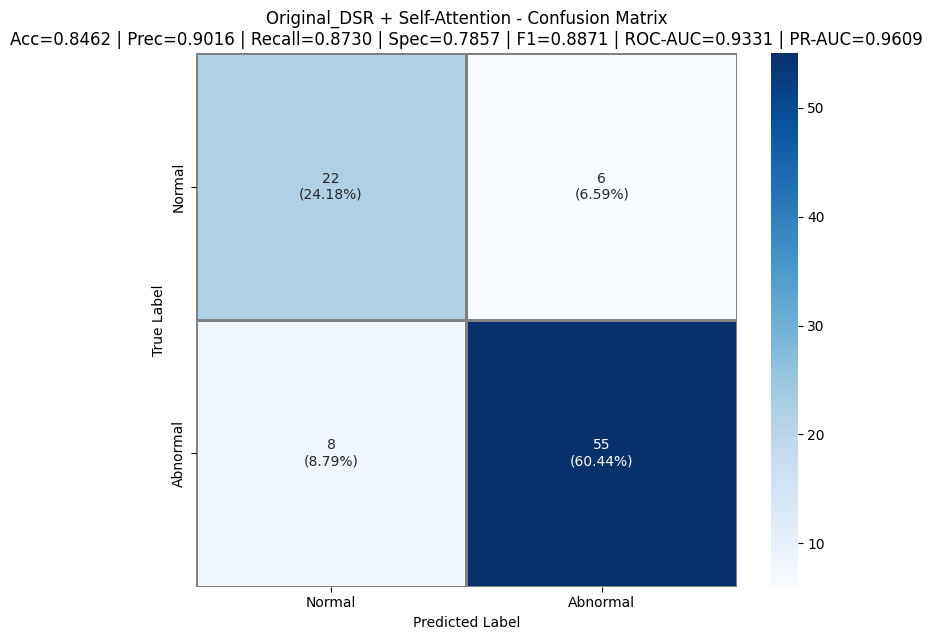

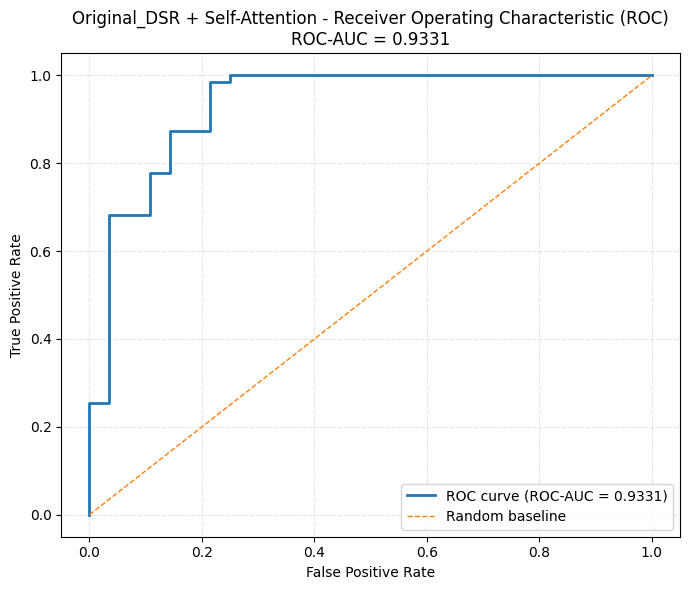

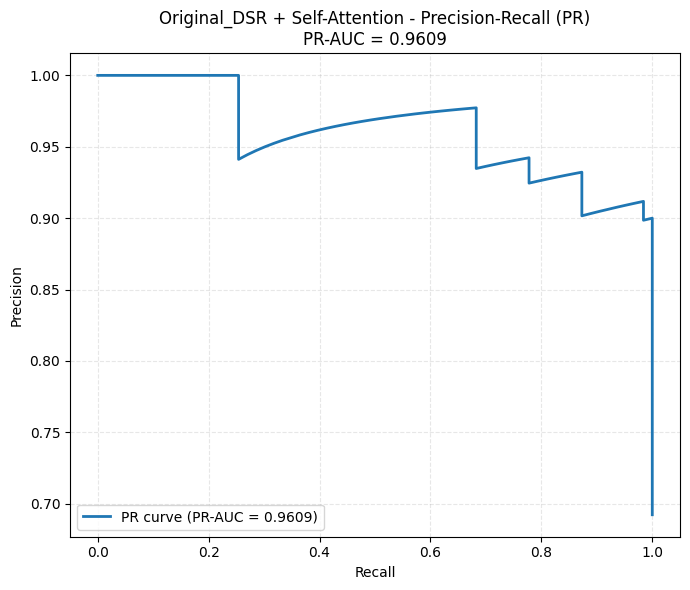

Saved 9 figures for Original_DSR_Attn -> C:\Users\LYG Y9000x\OneDrive\Desktop\proj new daima\outputs_ablation_original_dsr_binary\single_method_figures\Original_DSR_Attn
ROC-AUC (calculated): 0.9331
PR-AUC (calculated): 0.9609

[Original_DSR_RAG]
y_true: (91,)
y_pred: (91,)
y_score: (91,)


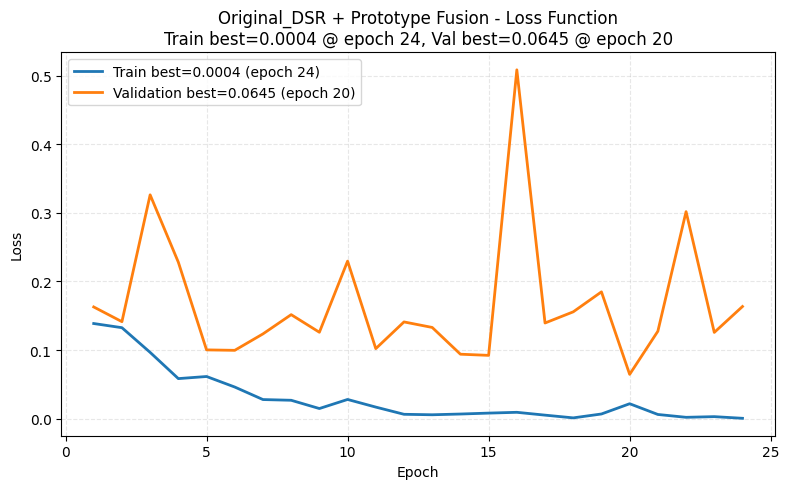

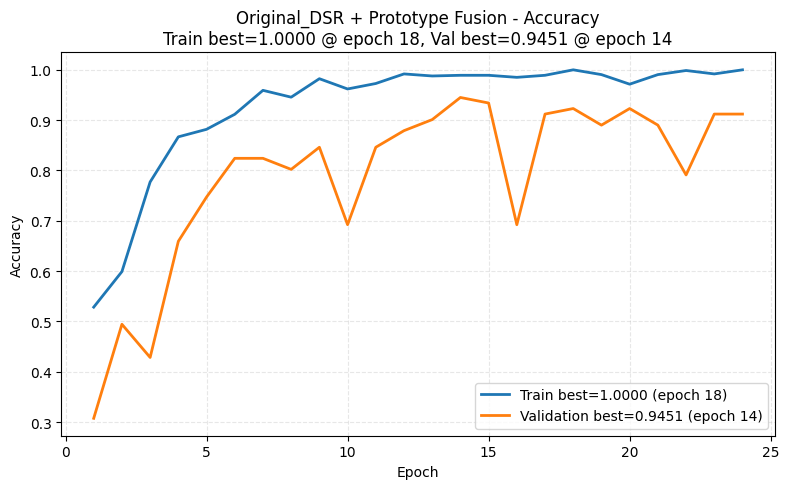

Skip Original_DSR + Prototype Fusion - Specificity (SP): missing train_specificity or val_specificity
Skip Original_DSR + Prototype Fusion - Sensitivity / Recall (SE): missing train_recall or val_recall
Skip Original_DSR + Prototype Fusion - Precision: missing train_precision or val_precision


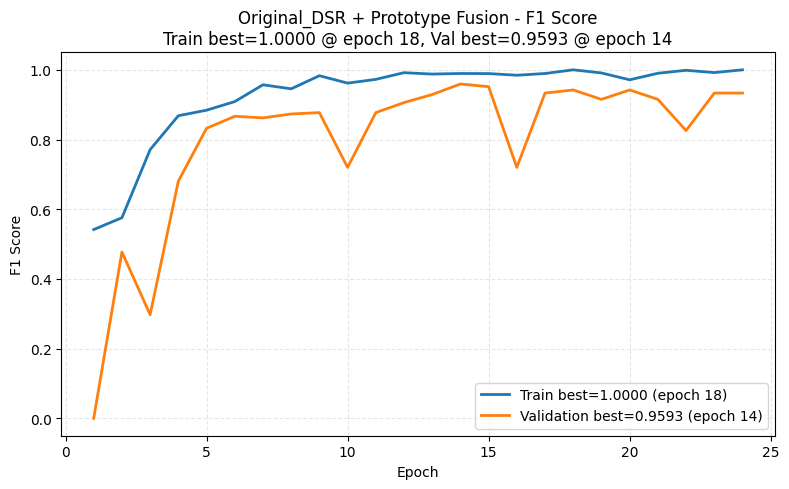

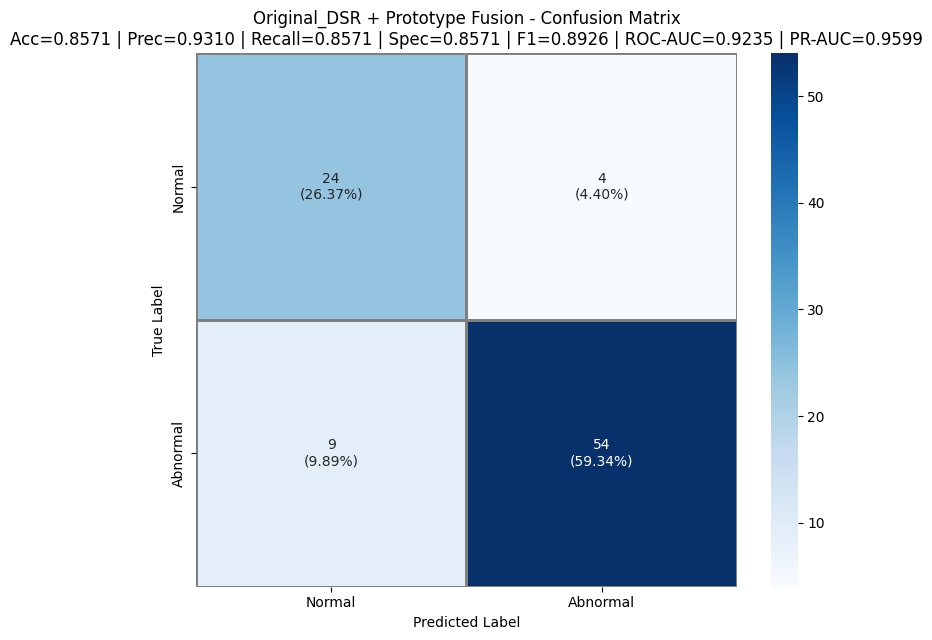

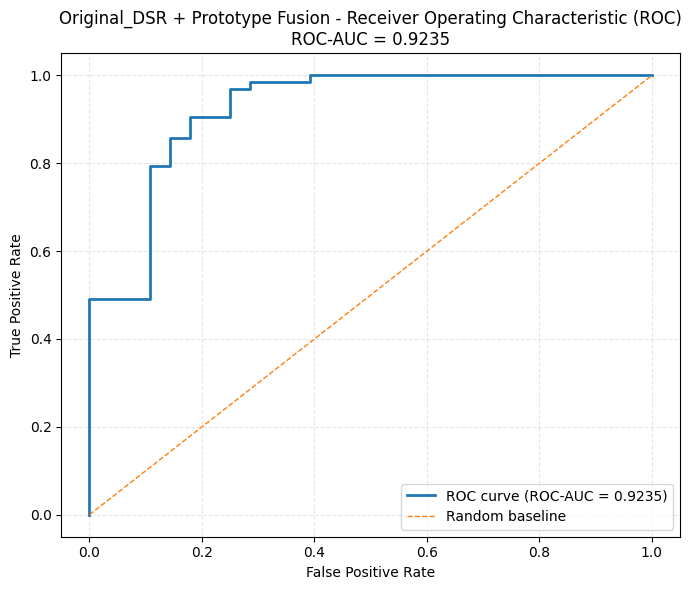

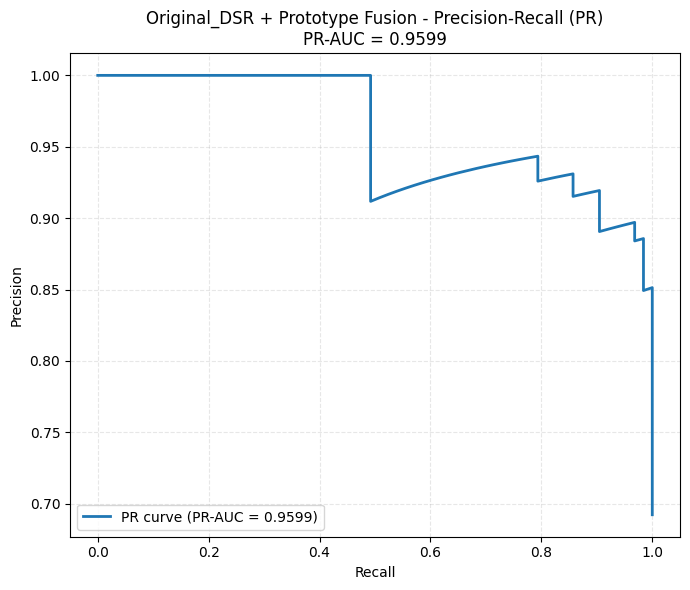

Saved 9 figures for Original_DSR_RAG -> C:\Users\LYG Y9000x\OneDrive\Desktop\proj new daima\outputs_ablation_original_dsr_binary\single_method_figures\Original_DSR_RAG
ROC-AUC (calculated): 0.9235
PR-AUC (calculated): 0.9599

[Original_DSR_Attn_RAG]
y_true: (91,)
y_pred: (91,)
y_score: (91,)


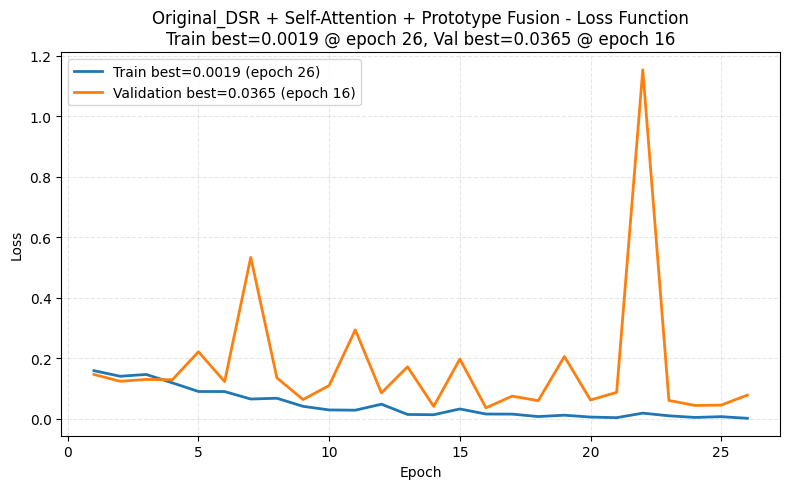

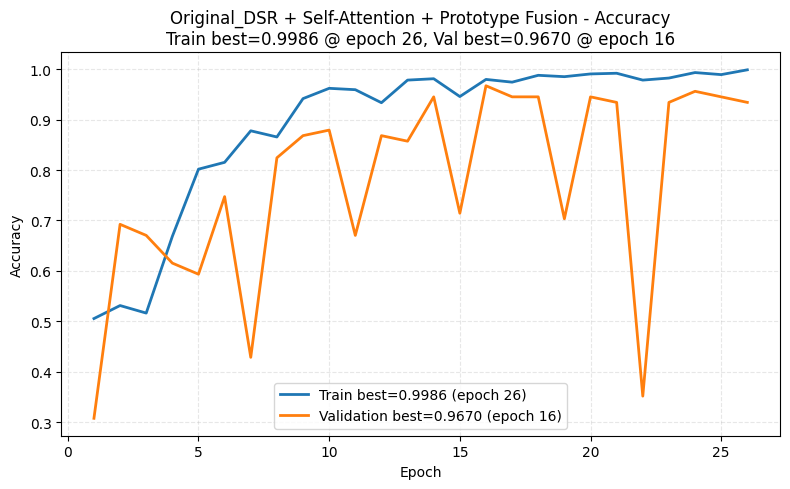

Skip Original_DSR + Self-Attention + Prototype Fusion - Specificity (SP): missing train_specificity or val_specificity
Skip Original_DSR + Self-Attention + Prototype Fusion - Sensitivity / Recall (SE): missing train_recall or val_recall
Skip Original_DSR + Self-Attention + Prototype Fusion - Precision: missing train_precision or val_precision


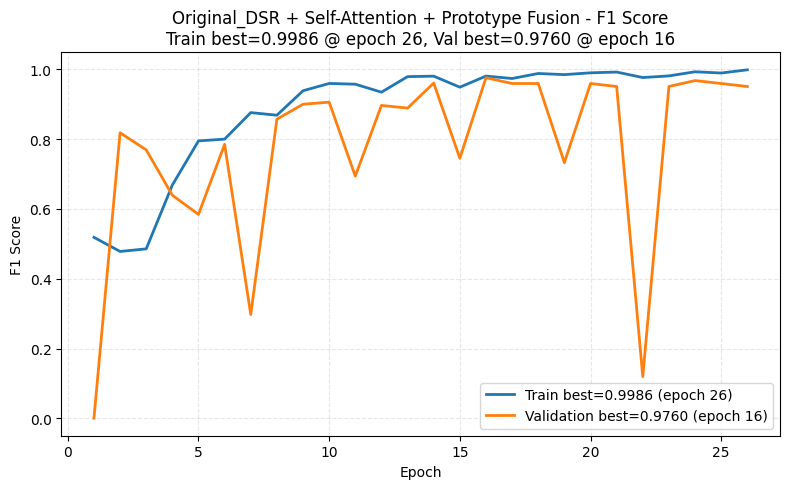

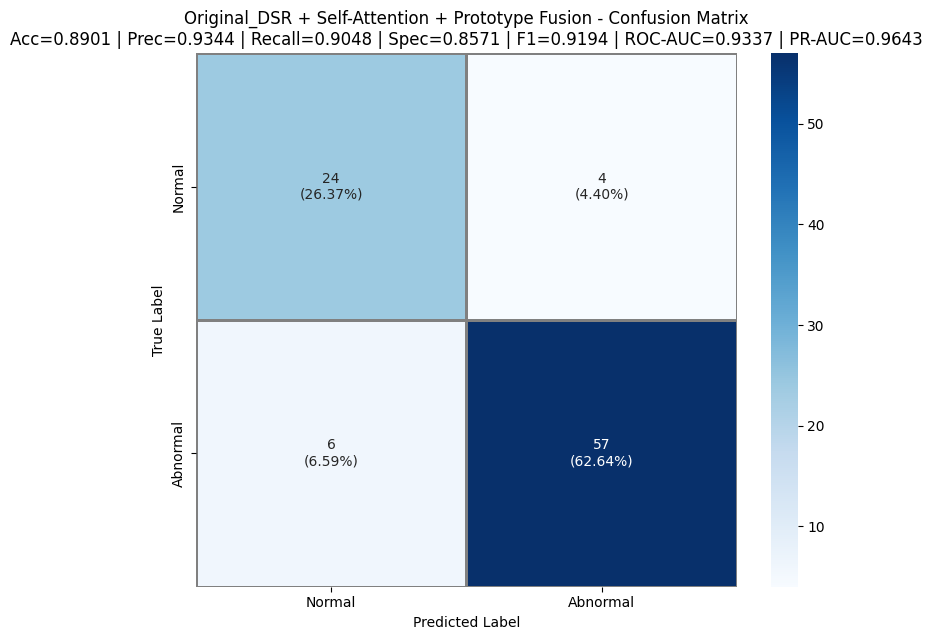

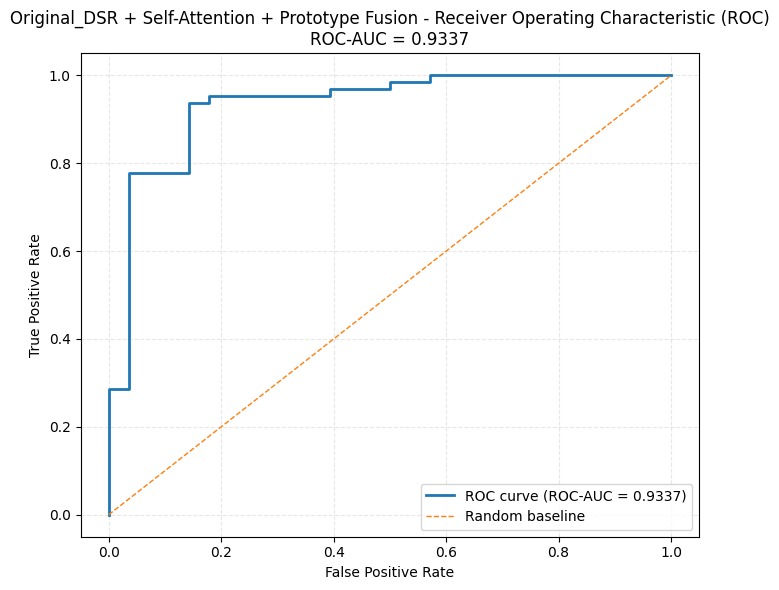

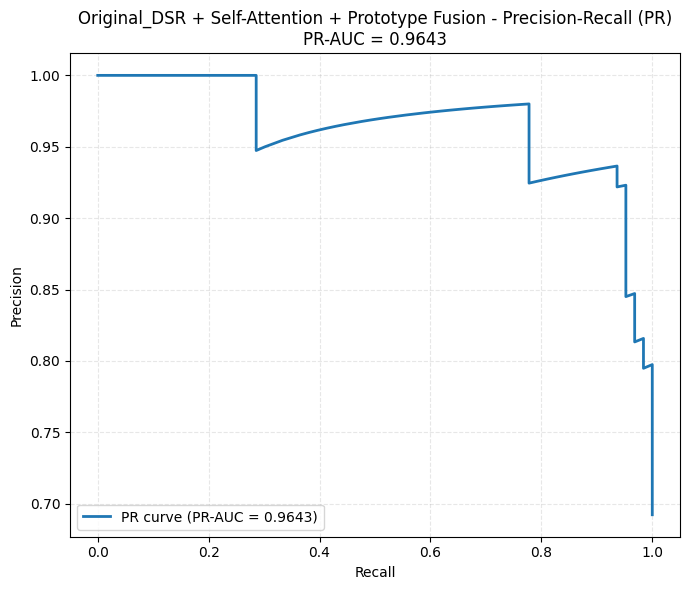

Saved 9 figures for Original_DSR_Attn_RAG -> C:\Users\LYG Y9000x\OneDrive\Desktop\proj new daima\outputs_ablation_original_dsr_binary\single_method_figures\Original_DSR_Attn_RAG
ROC-AUC (calculated): 0.9337
PR-AUC (calculated): 0.9643

All figures finished. Saved under: C:\Users\LYG Y9000x\OneDrive\Desktop\proj new daima\outputs_ablation_original_dsr_binary\single_method_figures


In [27]:
# =========================
# Generate 9 figures for each method
# Compatible with:
# results = {'models', 'histories', 'metrics', 'predictions'}
# Your current predictions format:
# pred_info = {
#     'y_true': (N,),
#     'y_prob': (N, 2)
# }
# =========================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# -------------------------
# Basic config
# -------------------------
try:
    CLASS_NAMES
except NameError:
    CLASS_NAMES = ["Normal", "Abnormal"]

try:
    OUT_DIR
except NameError:
    OUT_DIR = Path("./outputs_ablation")

OUT_DIR = Path(OUT_DIR)
TEST_FIG_DIR = OUT_DIR / "single_method_figures"
TEST_FIG_DIR.mkdir(parents=True, exist_ok=True)

DISPLAY_NAME_MAP = {
    "Original_DSR": "Original_DSR",
    "Original_DSR_Attn": "Original_DSR + Self-Attention",
    "Original_DSR_RAG": "Original_DSR + Prototype Fusion",
    "Original_DSR_Attn_RAG": "Original_DSR + Self-Attention + Prototype Fusion",
    "Original_DSR_Proto": "Original_DSR + Prototype Fusion",
    "Original_DSR_Attn_Proto": "Original_DSR + Self-Attention + Prototype Fusion",
}

def display_name(name):
    return DISPLAY_NAME_MAP.get(name, name.replace("RAG", "Prototype Fusion"))

def _get_first_valid(d, keys, default=None):
    if d is None:
        return default
    for k in keys:
        if k in d and d[k] is not None:
            return d[k]
    return default

def _best_value_and_epoch(values, lower_is_better=False):
    if values is None or len(values) == 0:
        return 0.0, 0
    best_val = min(values) if lower_is_better else max(values)
    best_epoch = list(values).index(best_val) + 1
    return float(best_val), int(best_epoch)

# -------------------------
# Score / prediction helpers
# -------------------------
def prepare_binary_score(y_score):
    """
    Convert model output scores to 1D positive-class score for binary ROC/PR.

    Supported:
    - shape (N,)   -> return as is
    - shape (N, 1) -> squeeze
    - shape (N, 2) -> take positive-class probability at column 1
    """
    if y_score is None:
        return None

    y_score = np.asarray(y_score)

    if y_score.ndim == 1:
        return y_score

    if y_score.ndim == 2:
        if y_score.shape[1] == 1:
            return y_score[:, 0]
        elif y_score.shape[1] == 2:
            return y_score[:, 1]
        else:
            raise ValueError(f"Unsupported y_score shape for binary task: {y_score.shape}")

    raise ValueError(f"Unsupported y_score ndim: {y_score.ndim}, shape={y_score.shape}")

def extract_prediction_arrays(pred_info):
    """
    For your current notebook:
    pred_info = {
        'y_true': (N,),
        'y_prob': (N, 2)
    }

    Returns:
    - y_true: (N,)
    - y_pred: (N,) from argmax over y_prob
    - y_score: (N,) positive-class probability for ROC/PR
    """
    if pred_info is None:
        return None, None, None

    y_true = pred_info.get("y_true", None)
    y_prob = pred_info.get("y_prob", None)

    if y_true is not None:
        y_true = np.asarray(y_true).reshape(-1)

    y_pred = None
    y_score = None

    if y_prob is not None:
        y_prob = np.asarray(y_prob)

        if y_prob.ndim == 2 and y_prob.shape[1] == 2:
            y_pred = np.argmax(y_prob, axis=1)
            y_score = y_prob[:, 1]
        elif y_prob.ndim == 2 and y_prob.shape[1] == 1:
            y_score = y_prob[:, 0]
            y_pred = (y_score >= 0.5).astype(int)
        elif y_prob.ndim == 1:
            y_score = y_prob
            y_pred = (y_score >= 0.5).astype(int)
        else:
            raise ValueError(f"Unsupported y_prob shape: {y_prob.shape}")

    return y_true, y_pred, y_score

# -------------------------
# Single curve plot
# -------------------------
def plot_curve(history, train_key, val_key, title, ylabel, save_path):
    train_values = history.get(train_key, [])
    val_values = history.get(val_key, [])

    if len(train_values) == 0 or len(val_values) == 0:
        print(f"Skip {title}: missing {train_key} or {val_key}")
        return

    epochs = range(1, len(train_values) + 1)
    lower_is_better = ("loss" in train_key.lower()) or ("loss" in val_key.lower())

    train_best, train_best_epoch = _best_value_and_epoch(train_values, lower_is_better)
    val_best, val_best_epoch = _best_value_and_epoch(val_values, lower_is_better)

    plt.figure(figsize=(8, 5))
    plt.plot(
        epochs,
        train_values,
        linewidth=2,
        label=f"Train best={train_best:.4f} (epoch {train_best_epoch})"
    )
    plt.plot(
        epochs,
        val_values,
        linewidth=2,
        label=f"Validation best={val_best:.4f} (epoch {val_best_epoch})"
    )

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(
        f"{title}\n"
        f"Train best={train_best:.4f} @ epoch {train_best_epoch}, "
        f"Val best={val_best:.4f} @ epoch {val_best_epoch}"
    )
    plt.grid(True, alpha=0.3, linestyle="--")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# -------------------------
# Confusion matrix
# -------------------------
def plot_confusion_matrix_from_preds(y_true, y_pred, class_names, title, save_path, metrics_text=None):
    if y_true is None:
        print(f"Skip {title}: y_true not found.")
        return
    if y_pred is None:
        print(f"Skip {title}: y_pred not found.")
        return

    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    cm = confusion_matrix(y_true, y_pred)
    total = cm.sum()
    cm_percent = (cm / total * 100.0) if total > 0 else np.zeros_like(cm, dtype=float)

    annot = np.empty_like(cm).astype(object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n({cm_percent[i, j]:.2f}%)"

    plt.figure(figsize=(7.5, 6.5))
    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=1,
        linecolor="gray",
        cbar=True
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"{title}\n{metrics_text}" if metrics_text else title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# -------------------------
# ROC
# -------------------------
def plot_roc_curve_from_preds(y_true, y_score, title, save_path):
    if y_true is None or y_score is None:
        print(f"Skip {title}: y_true or y_score not found.")
        return None

    y_true = np.asarray(y_true).reshape(-1)
    y_score = prepare_binary_score(y_score)

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 6))
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"ROC curve (ROC-AUC = {roc_auc:.4f})"
    )
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1,
        label="Random baseline"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title}\nROC-AUC = {roc_auc:.4f}")
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    return roc_auc

# -------------------------
# PR
# -------------------------
def plot_pr_curve_from_preds(y_true, y_score, title, save_path):
    if y_true is None or y_score is None:
        print(f"Skip {title}: y_true or y_score not found.")
        return None

    y_true = np.asarray(y_true).reshape(-1)
    y_score = prepare_binary_score(y_score)

    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)

    plt.figure(figsize=(7, 6))
    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=f"PR curve (PR-AUC = {pr_auc:.4f})"
    )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title}\nPR-AUC = {pr_auc:.4f}")
    plt.legend(loc="lower left")
    plt.grid(True, alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    return pr_auc

# -------------------------
# Generate all 9 figures for one method
# -------------------------
def plot_required_figures(model_name, history, metric_info, pred_info, save_dir):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    show_name = display_name(model_name)

    # metrics
    accuracy = _get_first_valid(metric_info, ["accuracy", "acc", "oa"], 0.0)
    precision = _get_first_valid(metric_info, ["precision", "prec"], 0.0)
    recall = _get_first_valid(metric_info, ["recall", "sensitivity"], 0.0)
    specificity = _get_first_valid(metric_info, ["specificity", "spec"], 0.0)
    f1 = _get_first_valid(metric_info, ["f1", "f1_score", "macro_f1"], 0.0)
    roc_auc_metric = _get_first_valid(metric_info, ["roc_auc", "auc"], None)
    pr_auc_metric = _get_first_valid(metric_info, ["pr_auc", "ap"], None)

    # predictions
    y_true, y_pred, y_score = extract_prediction_arrays(pred_info)

    print(f"\n[{model_name}]")
    print("y_true:", None if y_true is None else np.asarray(y_true).shape)
    print("y_pred:", None if y_pred is None else np.asarray(y_pred).shape)
    print("y_score:", None if y_score is None else np.asarray(y_score).shape)

    # 1 loss
    plot_curve(
        history, "train_loss", "val_loss",
        f"{show_name} - Loss Function",
        "Loss",
        save_dir / f"{model_name}_loss.png"
    )

    # 2 accuracy
    plot_curve(
        history, "train_acc", "val_acc",
        f"{show_name} - Accuracy",
        "Accuracy",
        save_dir / f"{model_name}_accuracy.png"
    )

    # 3 specificity
    plot_curve(
        history, "train_specificity", "val_specificity",
        f"{show_name} - Specificity (SP)",
        "Specificity",
        save_dir / f"{model_name}_specificity.png"
    )

    # 4 recall
    plot_curve(
        history, "train_recall", "val_recall",
        f"{show_name} - Sensitivity / Recall (SE)",
        "Recall",
        save_dir / f"{model_name}_recall.png"
    )

    # 5 precision
    plot_curve(
        history, "train_precision", "val_precision",
        f"{show_name} - Precision",
        "Precision",
        save_dir / f"{model_name}_precision.png"
    )

    # 6 f1
    plot_curve(
        history, "train_f1", "val_f1",
        f"{show_name} - F1 Score",
        "F1 Score",
        save_dir / f"{model_name}_f1.png"
    )

    # 7 confusion matrix
    roc_auc_show = float(roc_auc_metric) if roc_auc_metric is not None else 0.0
    pr_auc_show = float(pr_auc_metric) if pr_auc_metric is not None else 0.0

    metrics_text = (
        f"Acc={float(accuracy):.4f} | Prec={float(precision):.4f} | Recall={float(recall):.4f} | "
        f"Spec={float(specificity):.4f} | F1={float(f1):.4f} | "
        f"ROC-AUC={roc_auc_show:.4f} | PR-AUC={pr_auc_show:.4f}"
    )

    plot_confusion_matrix_from_preds(
        y_true=y_true,
        y_pred=y_pred,
        class_names=CLASS_NAMES,
        title=f"{show_name} - Confusion Matrix",
        save_path=save_dir / f"{model_name}_confusion_matrix.png",
        metrics_text=metrics_text
    )

    # 8 roc
    roc_auc_calc = plot_roc_curve_from_preds(
        y_true=y_true,
        y_score=y_score,
        title=f"{show_name} - Receiver Operating Characteristic (ROC)",
        save_path=save_dir / f"{model_name}_roc.png"
    )

    # 9 pr
    pr_auc_calc = plot_pr_curve_from_preds(
        y_true=y_true,
        y_score=y_score,
        title=f"{show_name} - Precision-Recall (PR)",
        save_path=save_dir / f"{model_name}_pr.png"
    )

    print(f"Saved 9 figures for {model_name} -> {save_dir}")
    if roc_auc_calc is not None:
        print(f"ROC-AUC (calculated): {roc_auc_calc:.4f}")
    if pr_auc_calc is not None:
        print(f"PR-AUC (calculated): {pr_auc_calc:.4f}")

# =========================
# Main execution
# =========================
if "results" not in globals():
    raise ValueError("`results` not found. Run training first.")

if "histories" not in results or "metrics" not in results or "predictions" not in results:
    raise ValueError("`results` must contain `histories`, `metrics`, and `predictions`.")

for model_name in results["histories"].keys():
    model_fig_dir = TEST_FIG_DIR / model_name
    model_fig_dir.mkdir(parents=True, exist_ok=True)

    plot_required_figures(
        model_name=model_name,
        history=results["histories"][model_name],
        metric_info=results["metrics"].get(model_name, {}),
        pred_info=results["predictions"].get(model_name, {}),
        save_dir=model_fig_dir
    )

print(f"\nAll figures finished. Saved under: {TEST_FIG_DIR}")

In [26]:
import numpy as np

for model_name, pred_info in results["predictions"].items():
    print(f"\n===== {model_name} =====")
    if isinstance(pred_info, dict):
        for k, v in pred_info.items():
            try:
                arr = np.asarray(v)
                print(f"{k}: shape={arr.shape}, dtype={arr.dtype}")
            except Exception:
                print(f"{k}: type={type(v)}")
    else:
        print(type(pred_info))


===== Original_DSR =====
y_true: shape=(91,), dtype=int64
y_prob: shape=(91, 2), dtype=float32

===== Original_DSR_Attn =====
y_true: shape=(91,), dtype=int64
y_prob: shape=(91, 2), dtype=float32

===== Original_DSR_RAG =====
y_true: shape=(91,), dtype=int64
y_prob: shape=(91, 2), dtype=float32

===== Original_DSR_Attn_RAG =====
y_true: shape=(91,), dtype=int64
y_prob: shape=(91, 2), dtype=float32
